# Hephaestus Agentic Maintenance — Data Exploration Report

**Objective:** Understand the full dataset landscape for the predictive/agentic maintenance system.

**Datasets available:**
| File | Description |
|------|-------------|
| `sensor_catalog.csv` | Metadata for every sensor installed across all machines |
| `sensor_readings.csv` | Time-series sensor measurements (~800 k rows) |
| `remaining_life.csv` | Current component health & remaining useful life |
| `interventions.csv` | Historical maintenance events (2022 → 2025) |

---

## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

DATA = Path('../data')

---
## 1 · Sensor Catalog

In [2]:
catalog = pd.read_csv(DATA / 'sensor_catalog.csv')
print(f'Shape: {catalog.shape}')
catalog.head()

Shape: (77, 16)


,sensor_id,tag,base_tag,sensor_name,machine,machine_type,machine_location,unit,nominal_value,warn_lo,warn_hi,crit_lo,crit_hi,fault_correlation,sampling_rate_sec,active
0,SNS-0001,HX-200-PS-101,PS-101,Pump Outlet Pressure,HX-200,hydraulic_press,Bay A - Press Shop,bar,200.0,150.0,260.0,100.0,280.0,"E-001,E-007",60,True
1,SNS-0002,HX-200-PS-201,PS-201,Valve Inlet Pressure,HX-200,hydraulic_press,Bay A - Press Shop,bar,195.0,145.0,255.0,95.0,270.0,E-001,60,True
2,SNS-0003,HX-200-PS-301,PS-301,Cylinder Pressure,HX-200,hydraulic_press,Bay A - Press Shop,bar,185.0,140.0,250.0,90.0,265.0,E-004,60,True
3,SNS-0004,HX-200-TS-101,TS-101,Oil Temperature,HX-200,hydraulic_press,Bay A - Press Shop,C,48.0,35.0,65.0,25.0,75.0,E-002,60,True
4,SNS-0005,HX-200-DP-201,DP-201,Filter Delta-P,HX-200,hydraulic_press,Bay A - Press Shop,bar,1.2,0.0,2.5,0.0,4.0,E-005,60,True


In [3]:
print('=== Basic info ===')
catalog.info()
print('\n=== Missing values ===')
print(catalog.isnull().sum())

=== Basic info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sensor_id          77 non-null     object 
 1   tag                77 non-null     object 
 2   base_tag           77 non-null     object 
 3   sensor_name        77 non-null     object 
 4   machine            77 non-null     object 
 5   machine_type       77 non-null     object 
 6   machine_location   77 non-null     object 
 7   unit               77 non-null     object 
 8   nominal_value      77 non-null     float64
 9   warn_lo            77 non-null     float64
 10  warn_hi            77 non-null     float64
 11  crit_lo            77 non-null     float64
 12  crit_hi            77 non-null     float64
 13  fault_correlation  77 non-null     object 
 14  sampling_rate_sec  77 non-null     int64  
 15  active             77 non-null     bool   
dtypes: bool(1

### 1.1 · Machine & Type Distribution

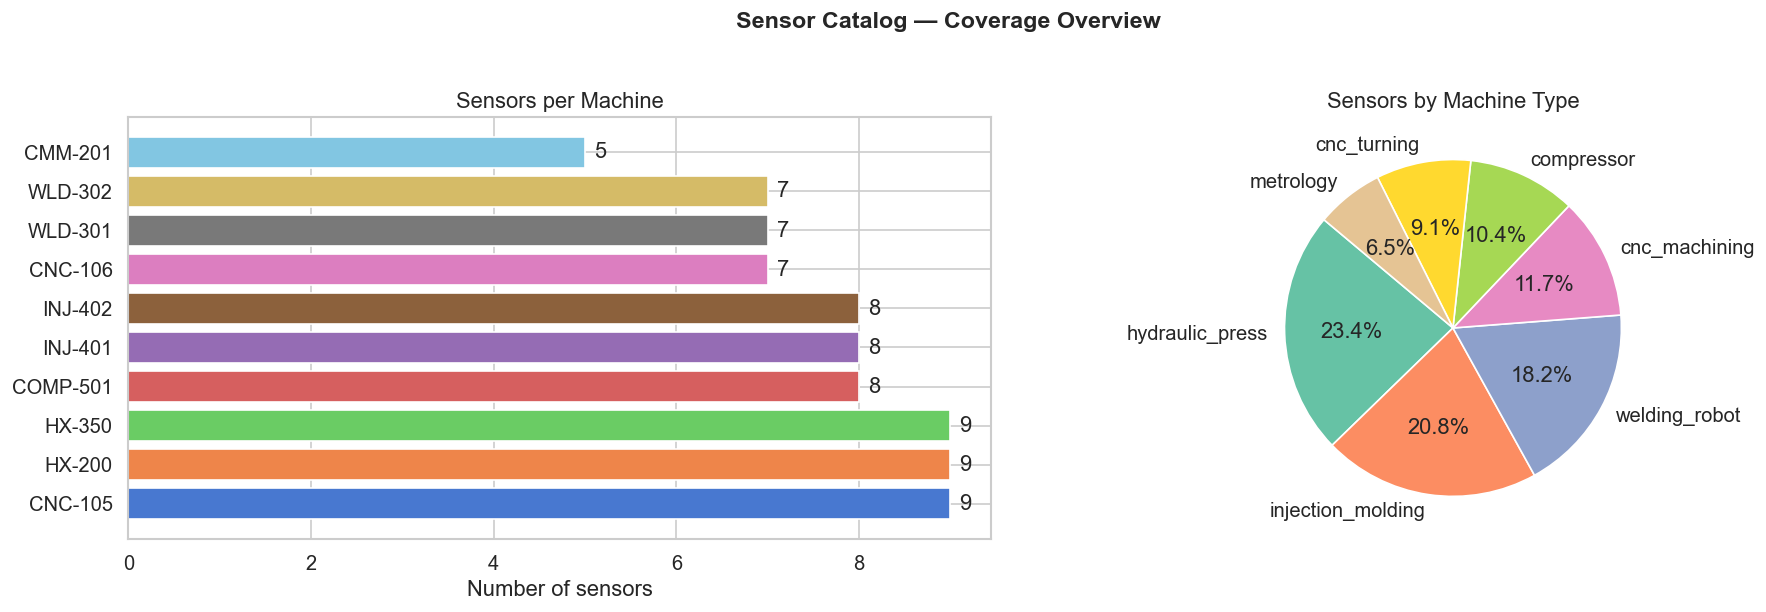

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sensors_per_machine = catalog.groupby('machine').size().sort_values(ascending=False)
axes[0].barh(sensors_per_machine.index, sensors_per_machine.values,
             color=sns.color_palette('muted', len(sensors_per_machine)))
axes[0].set_xlabel('Number of sensors')
axes[0].set_title('Sensors per Machine')
for i, v in enumerate(sensors_per_machine.values):
    axes[0].text(v + 0.1, i, str(v), va='center')

sensors_per_type = catalog.groupby('machine_type').size().sort_values(ascending=False)
colors = sns.color_palette('Set2', len(sensors_per_type))
axes[1].pie(sensors_per_type.values, labels=sensors_per_type.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Sensors by Machine Type')

plt.suptitle('Sensor Catalog — Coverage Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.2 · Sensor Units & Threshold Analysis

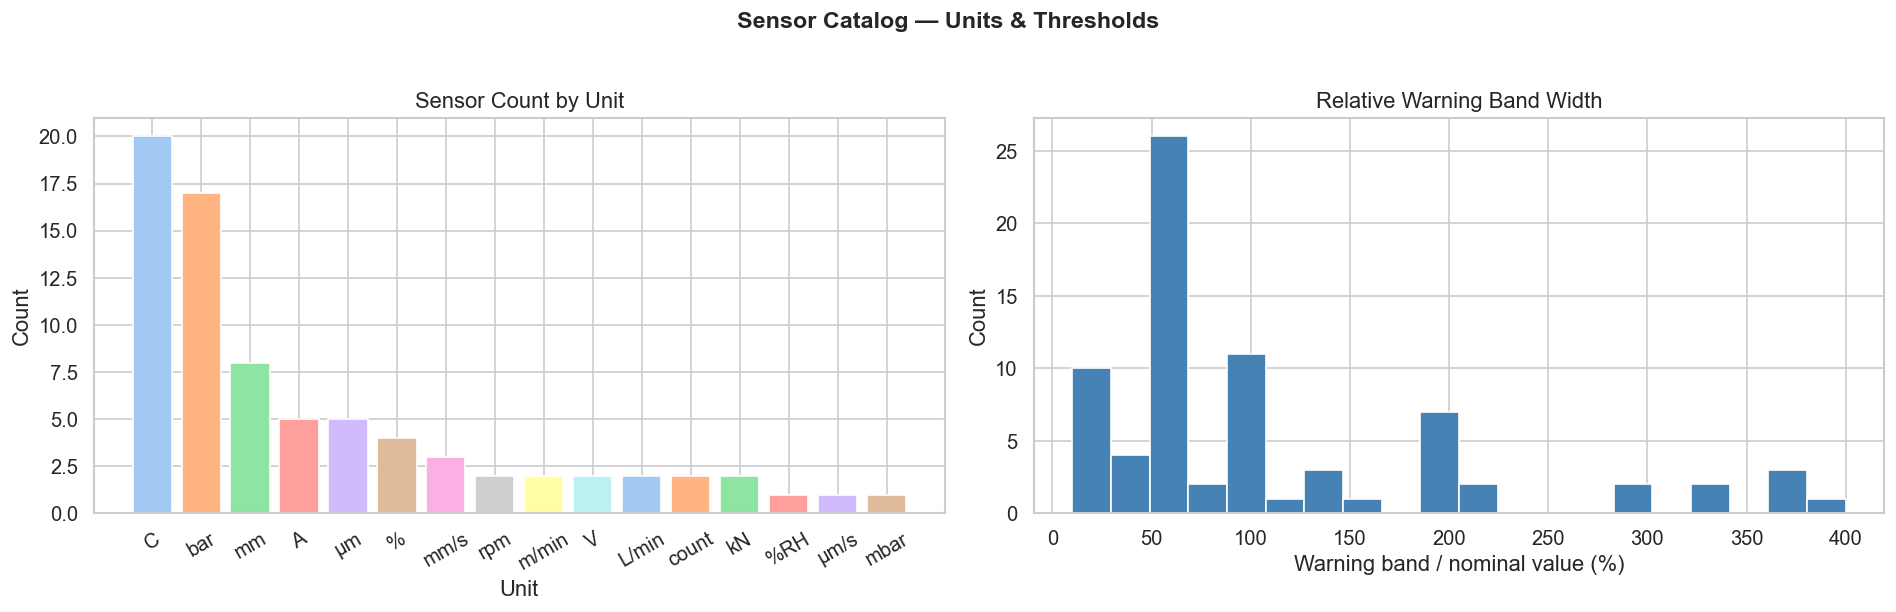

Sampling rates (sec): [60]
Active sensors: {True: 77}

Sensors per location:
machine_location
Bay A - Press Shop     18
Bay B - Machining      16
Bay E - Molding        16
Bay C - Welding        14
Utilities Room          8
Bay D - Quality Lab     5


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

unit_counts = catalog['unit'].value_counts()
axes[0].bar(unit_counts.index, unit_counts.values,
            color=sns.color_palette('pastel', len(unit_counts)))
axes[0].set_xlabel('Unit')
axes[0].set_ylabel('Count')
axes[0].set_title('Sensor Count by Unit')
axes[0].tick_params(axis='x', rotation=30)

catalog['warn_range'] = catalog['warn_hi'] - catalog['warn_lo']
catalog['nominal_pct_range'] = (catalog['warn_range'] / catalog['nominal_value'].abs().replace(0, np.nan)) * 100
axes[1].hist(catalog['nominal_pct_range'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Warning band / nominal value (%)')
axes[1].set_ylabel('Count')
axes[1].set_title('Relative Warning Band Width')

plt.suptitle('Sensor Catalog — Units & Thresholds', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Sampling rates (sec):', catalog['sampling_rate_sec'].unique())
print('Active sensors:', catalog['active'].value_counts().to_dict())
print('\nSensors per location:')
print(catalog.groupby('machine_location')['sensor_id'].count().sort_values(ascending=False).to_string())

---
## 2 · Sensor Readings

In [6]:
readings = pd.read_csv(DATA / 'sensor_readings.csv', parse_dates=['timestamp'])
print(f'Shape: {readings.shape}')
readings.head()

Shape: (800035, 12)


,id,timestamp,machine,machine_type,tag,sensor_name,value,unit,status,warn_lo,warn_hi,fault_corr
0,0,2024-07-01,HX-200,hydraulic_press,PS-101,Pump Outlet Pressure,191.689,bar,NORMAL,150.0,260.0,"E-001,E-007"
1,1,2024-07-01,HX-200,hydraulic_press,PS-201,Valve Inlet Pressure,197.012,bar,NORMAL,145.0,255.0,E-001
2,2,2024-07-01,HX-200,hydraulic_press,PS-301,Cylinder Pressure,186.993,bar,NORMAL,140.0,250.0,E-004
3,3,2024-07-01,HX-200,hydraulic_press,TS-101,Oil Temperature,46.063,C,NORMAL,35.0,65.0,E-002
4,4,2024-07-01,HX-200,hydraulic_press,DP-201,Filter Delta-P,1.177,bar,NORMAL,0.0,2.5,E-005


In [31]:
readings.info()
print('\n=== Nulls ===')
print(readings.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800035 entries, 0 to 800034
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            800035 non-null  int64         
 1   timestamp     800035 non-null  datetime64[ns]
 2   machine       800035 non-null  object        
 3   machine_type  800035 non-null  object        
 4   tag           800035 non-null  object        
 5   sensor_name   800035 non-null  object        
 6   value         800035 non-null  float64       
 7   unit          800035 non-null  object        
 8   status        800035 non-null  object        
 9   warn_lo       800035 non-null  float64       
 10  warn_hi       800035 non-null  float64       
 11  fault_corr    800035 non-null  object        
 12  date          800035 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(8)
memory usage: 79.3+ MB

=== Nulls ===
id              0
timestamp

### 2.1 · Temporal Coverage

Date range: 2024-07-01 00:00:00  →  2024-12-18 22:45:00
Duration  : 170 days


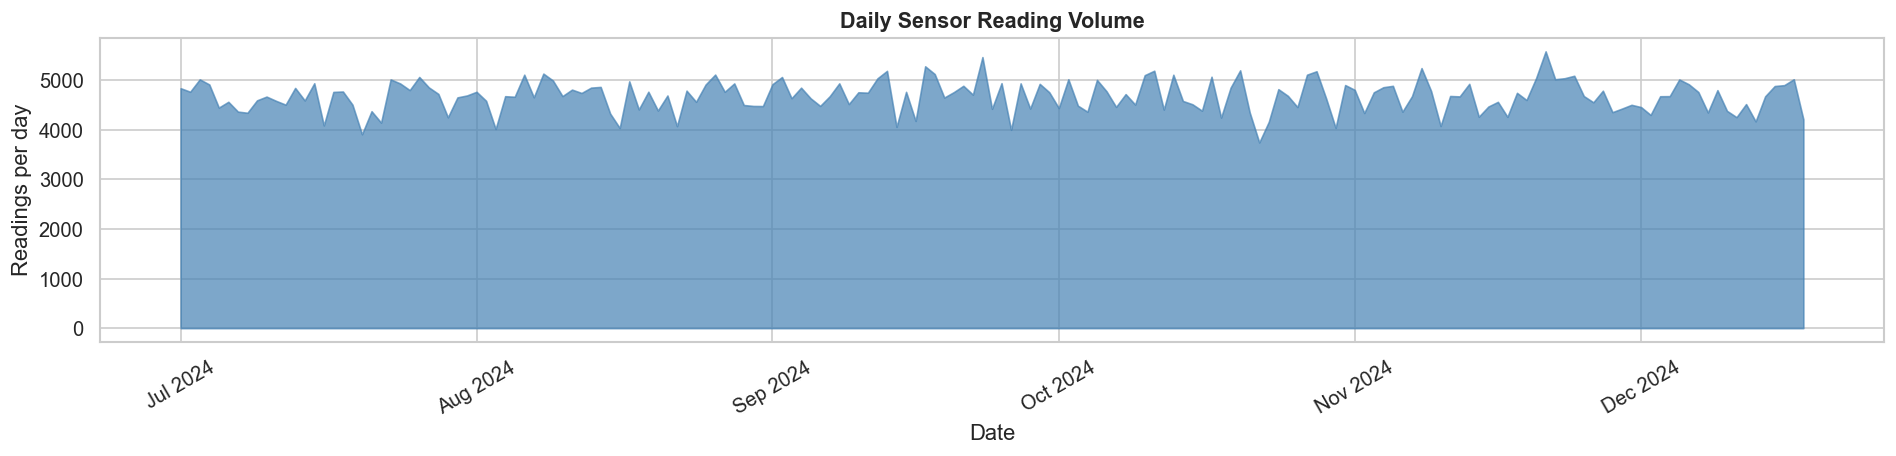

In [7]:
print(f'Date range: {readings["timestamp"].min()}  →  {readings["timestamp"].max()}')
print(f'Duration  : {(readings["timestamp"].max() - readings["timestamp"].min()).days} days')

readings['date'] = readings['timestamp'].dt.date
daily = readings.groupby('date').size().reset_index(name='count')
daily['date'] = pd.to_datetime(daily['date'])

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(daily['date'], daily['count'], alpha=0.7, color='steelblue')
ax.set_xlabel('Date')
ax.set_ylabel('Readings per day')
ax.set_title('Daily Sensor Reading Volume', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 2.2 · Status Distribution

Overall status breakdown:
status
NORMAL      772009
WARNING      23871
CRITICAL      4155
Name: count, dtype: int64

Abnormal readings: 28,026 (3.50%)


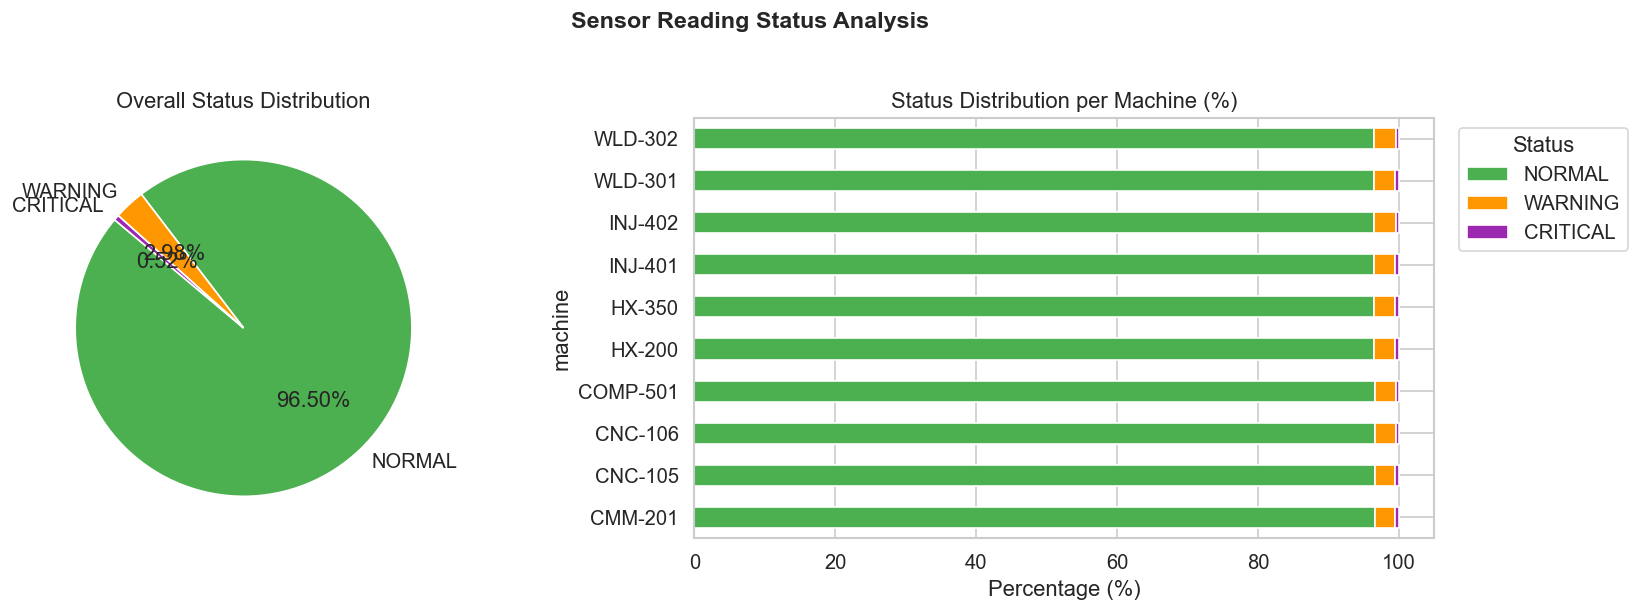

In [8]:
status_counts = readings['status'].value_counts()
print('Overall status breakdown:')
print(status_counts)
print(f'\nAbnormal readings: {(readings["status"] != "NORMAL").sum():,} '
      f'({(readings["status"] != "NORMAL").mean()*100:.2f}%)')

status_colors = {'NORMAL': '#4CAF50', 'WARNING': '#FF9800', 'FAULT': '#F44336', 'CRITICAL': '#9C27B0'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pie_colors = [status_colors.get(s, 'grey') for s in status_counts.index]
axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.2f%%',
            colors=pie_colors, startangle=140)
axes[0].set_title('Overall Status Distribution')

status_by_machine = readings.groupby(['machine', 'status']).size().unstack(fill_value=0)
status_by_machine_pct = status_by_machine.div(status_by_machine.sum(axis=1), axis=0) * 100
status_order = [c for c in ['NORMAL', 'WARNING', 'FAULT', 'CRITICAL'] if c in status_by_machine_pct.columns]
bar_colors = [status_colors.get(s, 'grey') for s in status_order]
status_by_machine_pct[status_order].plot(kind='barh', stacked=True, ax=axes[1],
                                          color=bar_colors, edgecolor='white')
axes[1].set_xlabel('Percentage (%)')
axes[1].set_title('Status Distribution per Machine (%)')
axes[1].legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle('Sensor Reading Status Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.3 · Readings per Machine & Machine Type

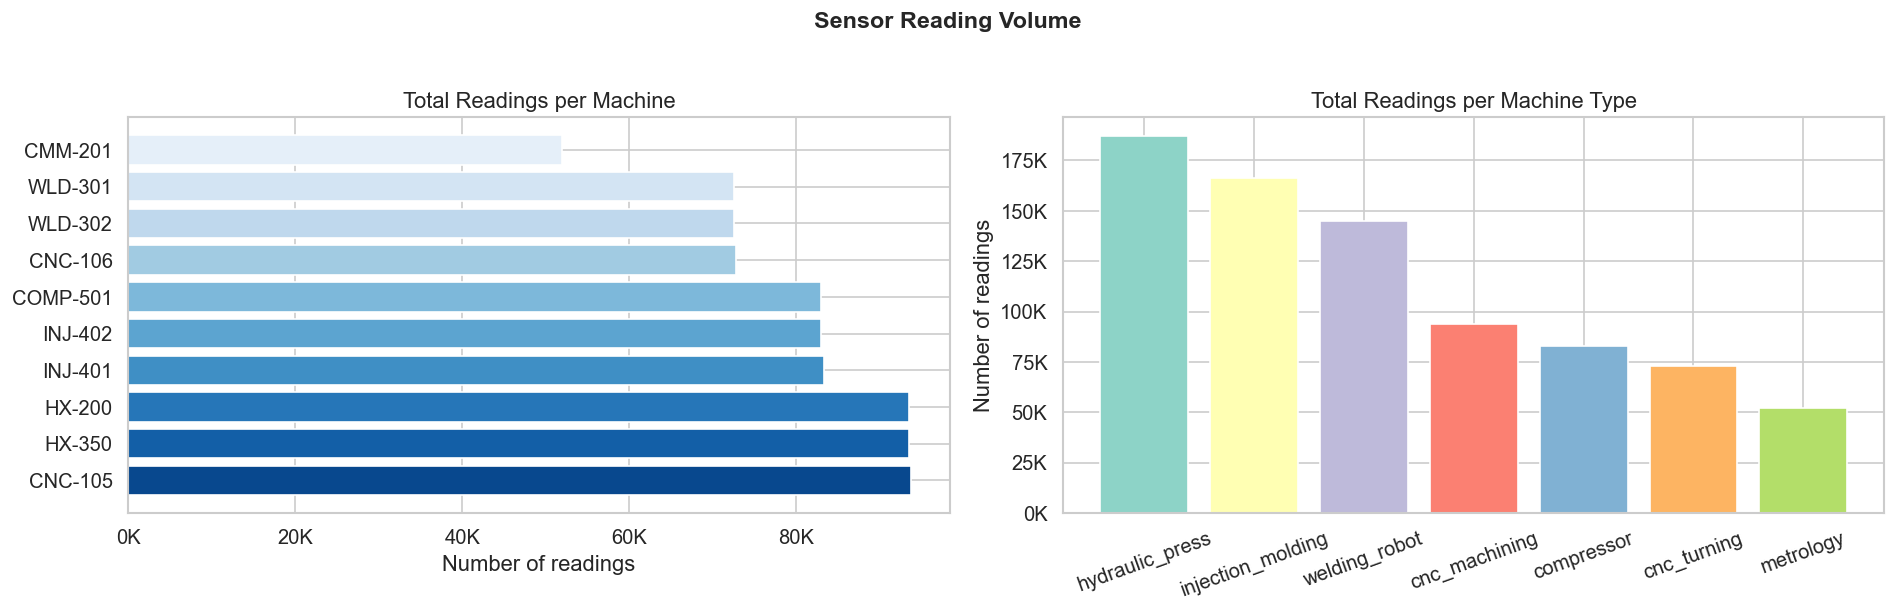

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

readings_per_machine = readings.groupby('machine').size().sort_values(ascending=False)
axes[0].barh(readings_per_machine.index, readings_per_machine.values,
             color=sns.color_palette('Blues_r', len(readings_per_machine)))
axes[0].set_xlabel('Number of readings')
axes[0].set_title('Total Readings per Machine')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

readings_per_type = readings.groupby('machine_type').size().sort_values(ascending=False)
axes[1].bar(readings_per_type.index, readings_per_type.values,
            color=sns.color_palette('Set3', len(readings_per_type)))
axes[1].set_ylabel('Number of readings')
axes[1].set_title('Total Readings per Machine Type')
axes[1].tick_params(axis='x', rotation=20)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.suptitle('Sensor Reading Volume', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.4 · Value Distribution per Sensor (Z-normalized)

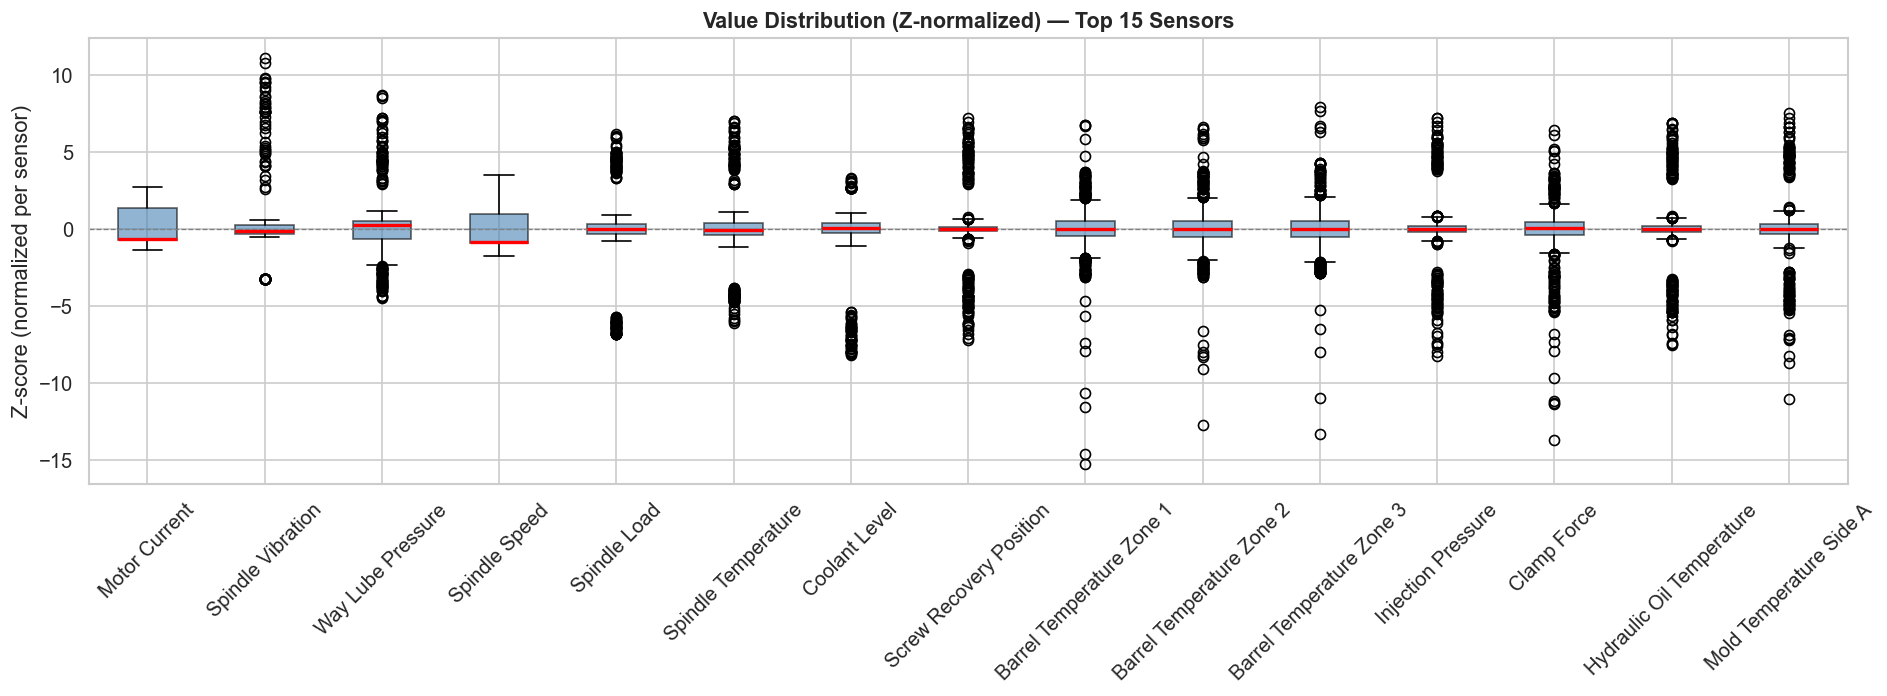

In [10]:
top_sensors = readings['sensor_name'].value_counts().head(15).index
sample = readings[readings['sensor_name'].isin(top_sensors)].sample(min(50000, len(readings)), random_state=42)

data_box, labels_box = [], []
for sn in top_sensors:
    sub = sample[sample['sensor_name'] == sn]['value'].dropna()
    if len(sub) > 10:
        z = (sub - sub.mean()) / (sub.std() + 1e-9)
        data_box.append(z.values)
        labels_box.append(sn)

fig, ax = plt.subplots(figsize=(16, 6))
ax.boxplot(data_box, vert=True, labels=labels_box, patch_artist=True,
           medianprops={'color': 'red', 'linewidth': 2},
           boxprops={'facecolor': 'steelblue', 'alpha': 0.6})
ax.set_ylabel('Z-score (normalized per sensor)')
ax.set_title('Value Distribution (Z-normalized) — Top 15 Sensors', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

### 2.5 · Fault Code Frequency in Abnormal Readings

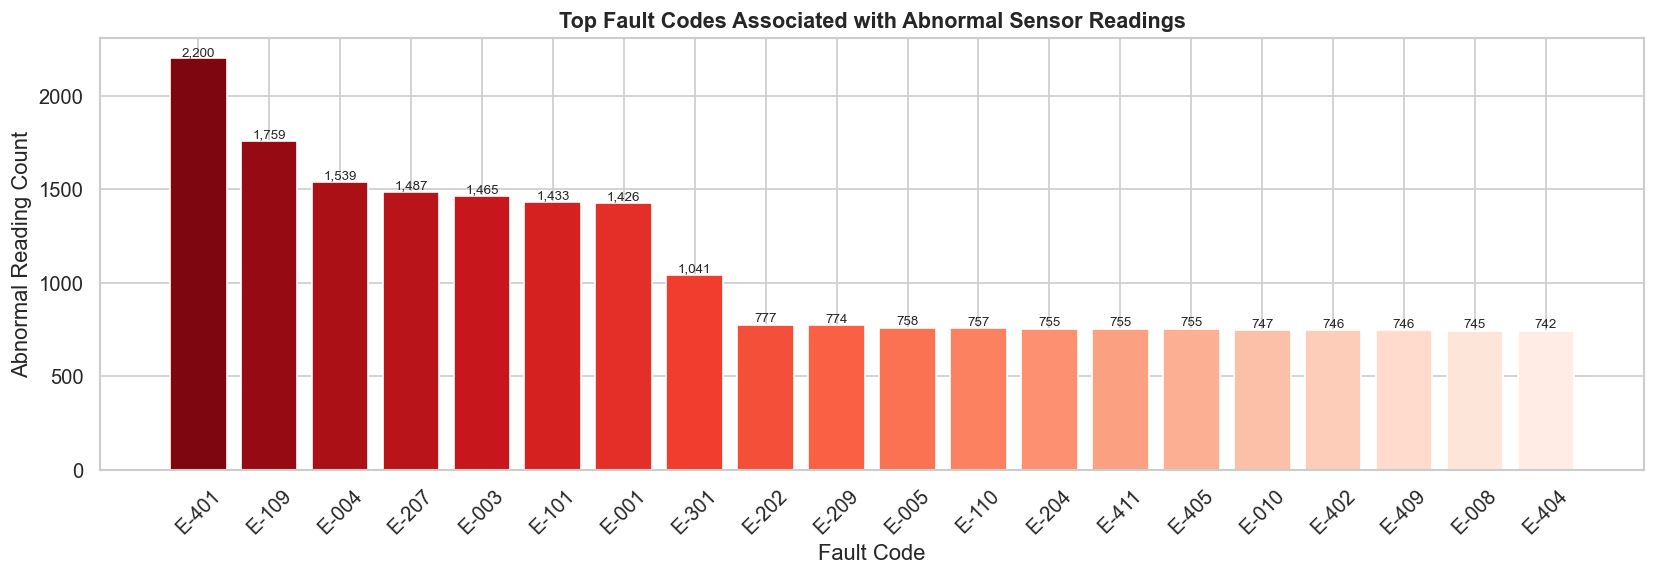

In [11]:
abnormal = readings[readings['status'].isin(['WARNING', 'FAULT', 'CRITICAL'])].copy()
abnormal['fault_corr'] = abnormal['fault_corr'].fillna('')
fault_exploded = abnormal['fault_corr'].str.split(',').explode().str.strip()
fault_counts = fault_exploded[fault_exploded != ''].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(fault_counts.index, fault_counts.values,
              color=sns.color_palette('Reds_r', len(fault_counts)))
ax.set_xlabel('Fault Code')
ax.set_ylabel('Abnormal Reading Count')
ax.set_title('Top Fault Codes Associated with Abnormal Sensor Readings', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### 2.6 · Time-Series Deep Dive — HX-200 Hydraulic Press

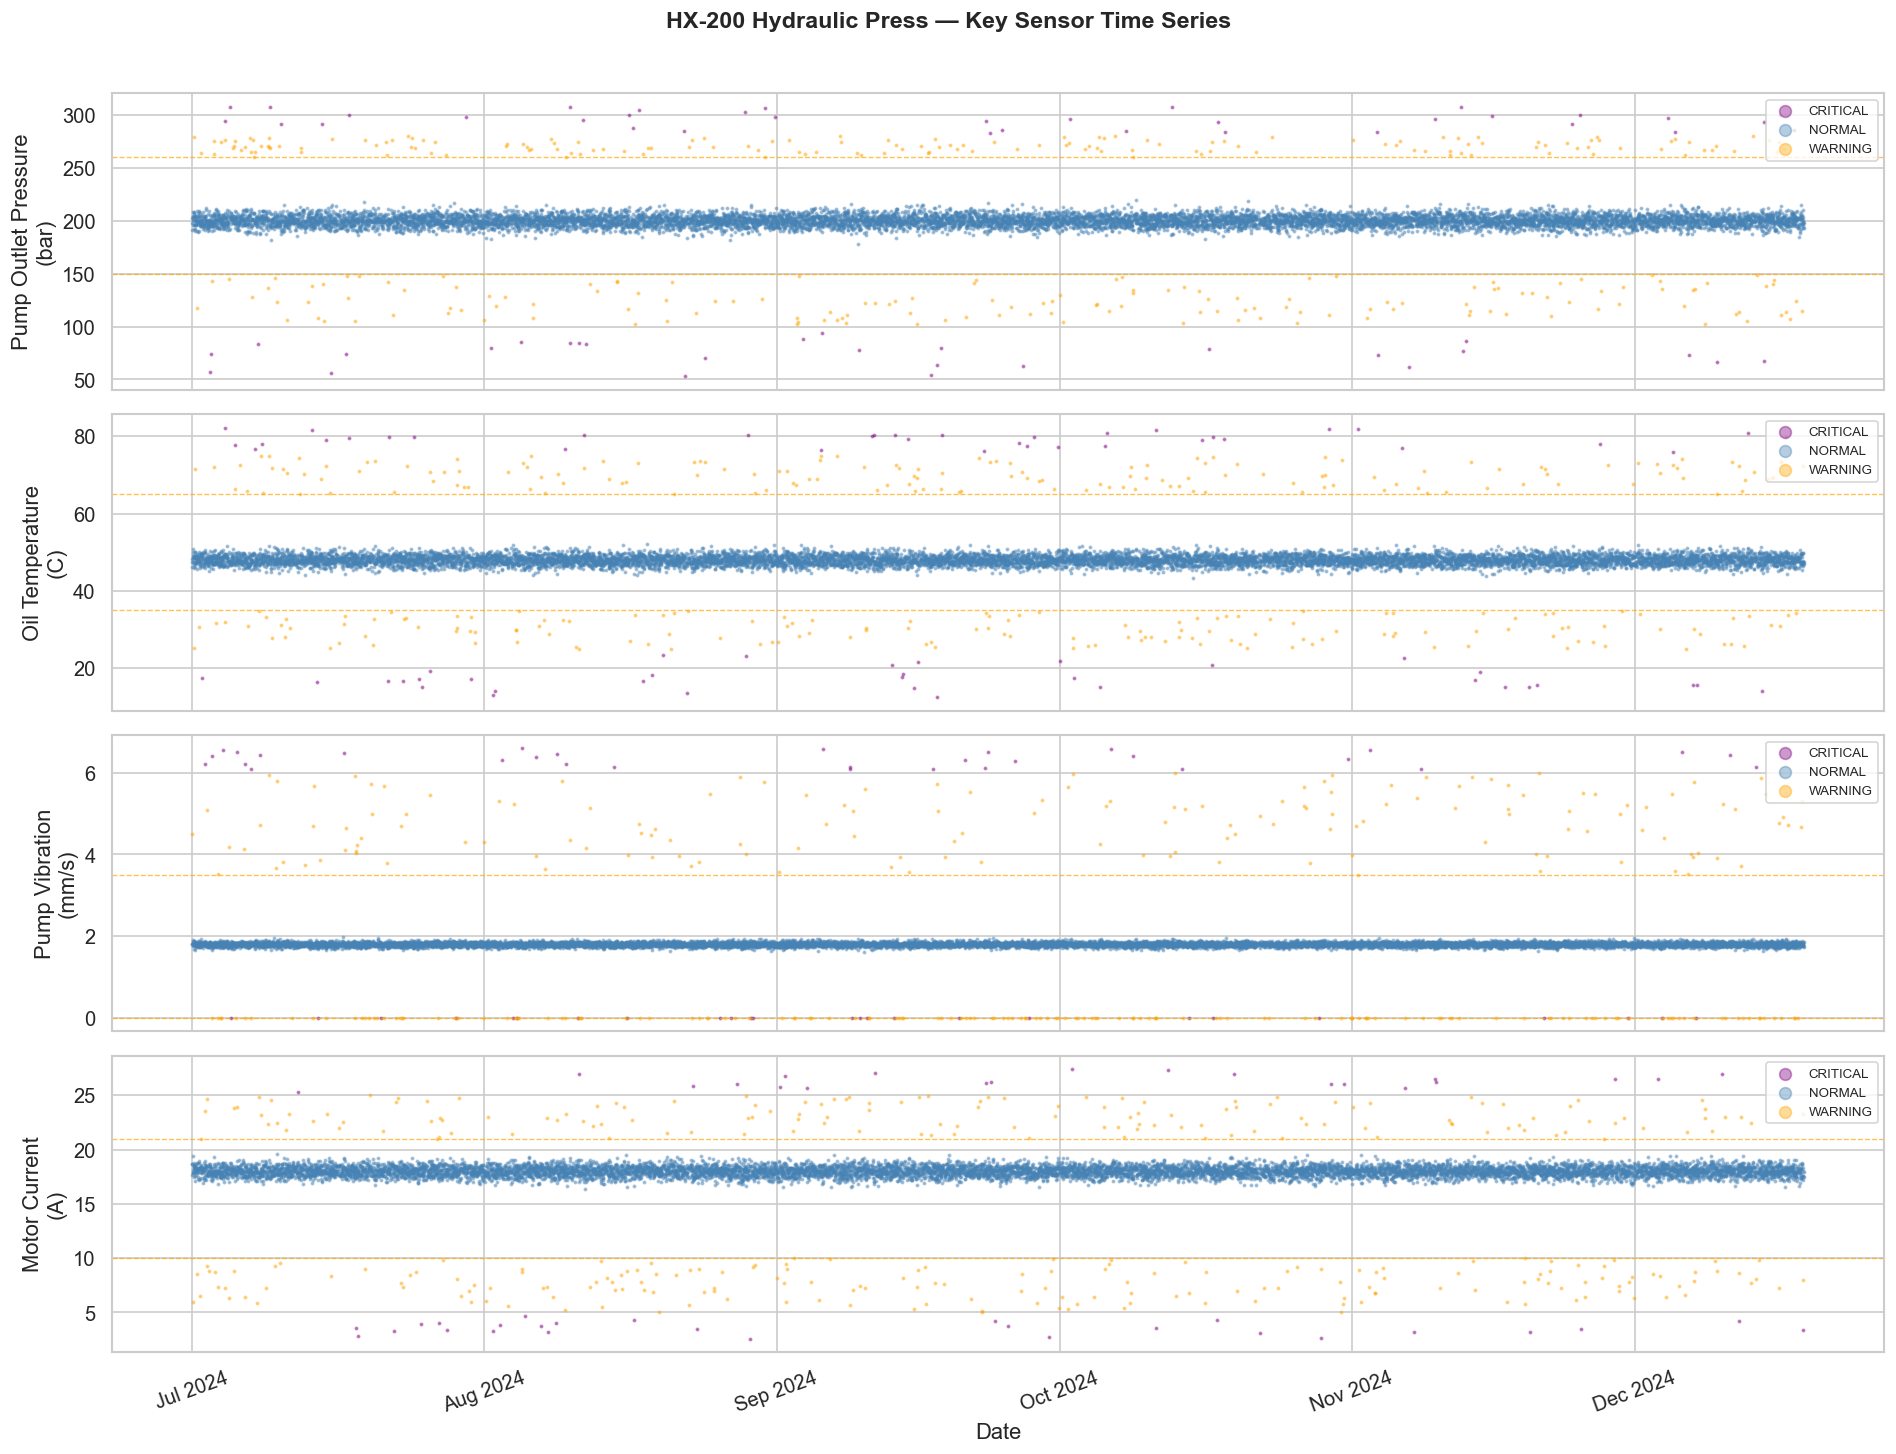

In [12]:
hx200 = readings[readings['machine'] == 'HX-200'].copy().sort_values('timestamp')
key_sensors = ['Pump Outlet Pressure', 'Oil Temperature', 'Pump Vibration', 'Motor Current']
available = [s for s in key_sensors if s in hx200['sensor_name'].unique()]

fig, axes = plt.subplots(len(available), 1, figsize=(16, 3 * len(available)), sharex=True)
if len(available) == 1:
    axes = [axes]

for ax, sname in zip(axes, available):
    sub = hx200[hx200['sensor_name'] == sname]
    for st, grp in sub.groupby('status'):
        sc = {'NORMAL': 'steelblue', 'WARNING': 'orange', 'FAULT': 'red', 'CRITICAL': 'purple'}
        ax.scatter(grp['timestamp'], grp['value'], s=2, alpha=0.4,
                   color=sc.get(st, 'grey'), label=st)
    cat_row = catalog[(catalog['machine'] == 'HX-200') & (catalog['sensor_name'] == sname)]
    if not cat_row.empty:
        ax.axhline(cat_row.iloc[0]['warn_lo'], color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.axhline(cat_row.iloc[0]['warn_hi'], color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
    unit = sub.iloc[0]['unit'] if len(sub) else ''
    ax.set_ylabel(f'{sname}\n({unit})')
    ax.legend(loc='upper right', markerscale=5, fontsize=8)

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=20)
plt.suptitle('HX-200 Hydraulic Press — Key Sensor Time Series', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.7 · Inter-Sensor Pearson Correlation per Machine

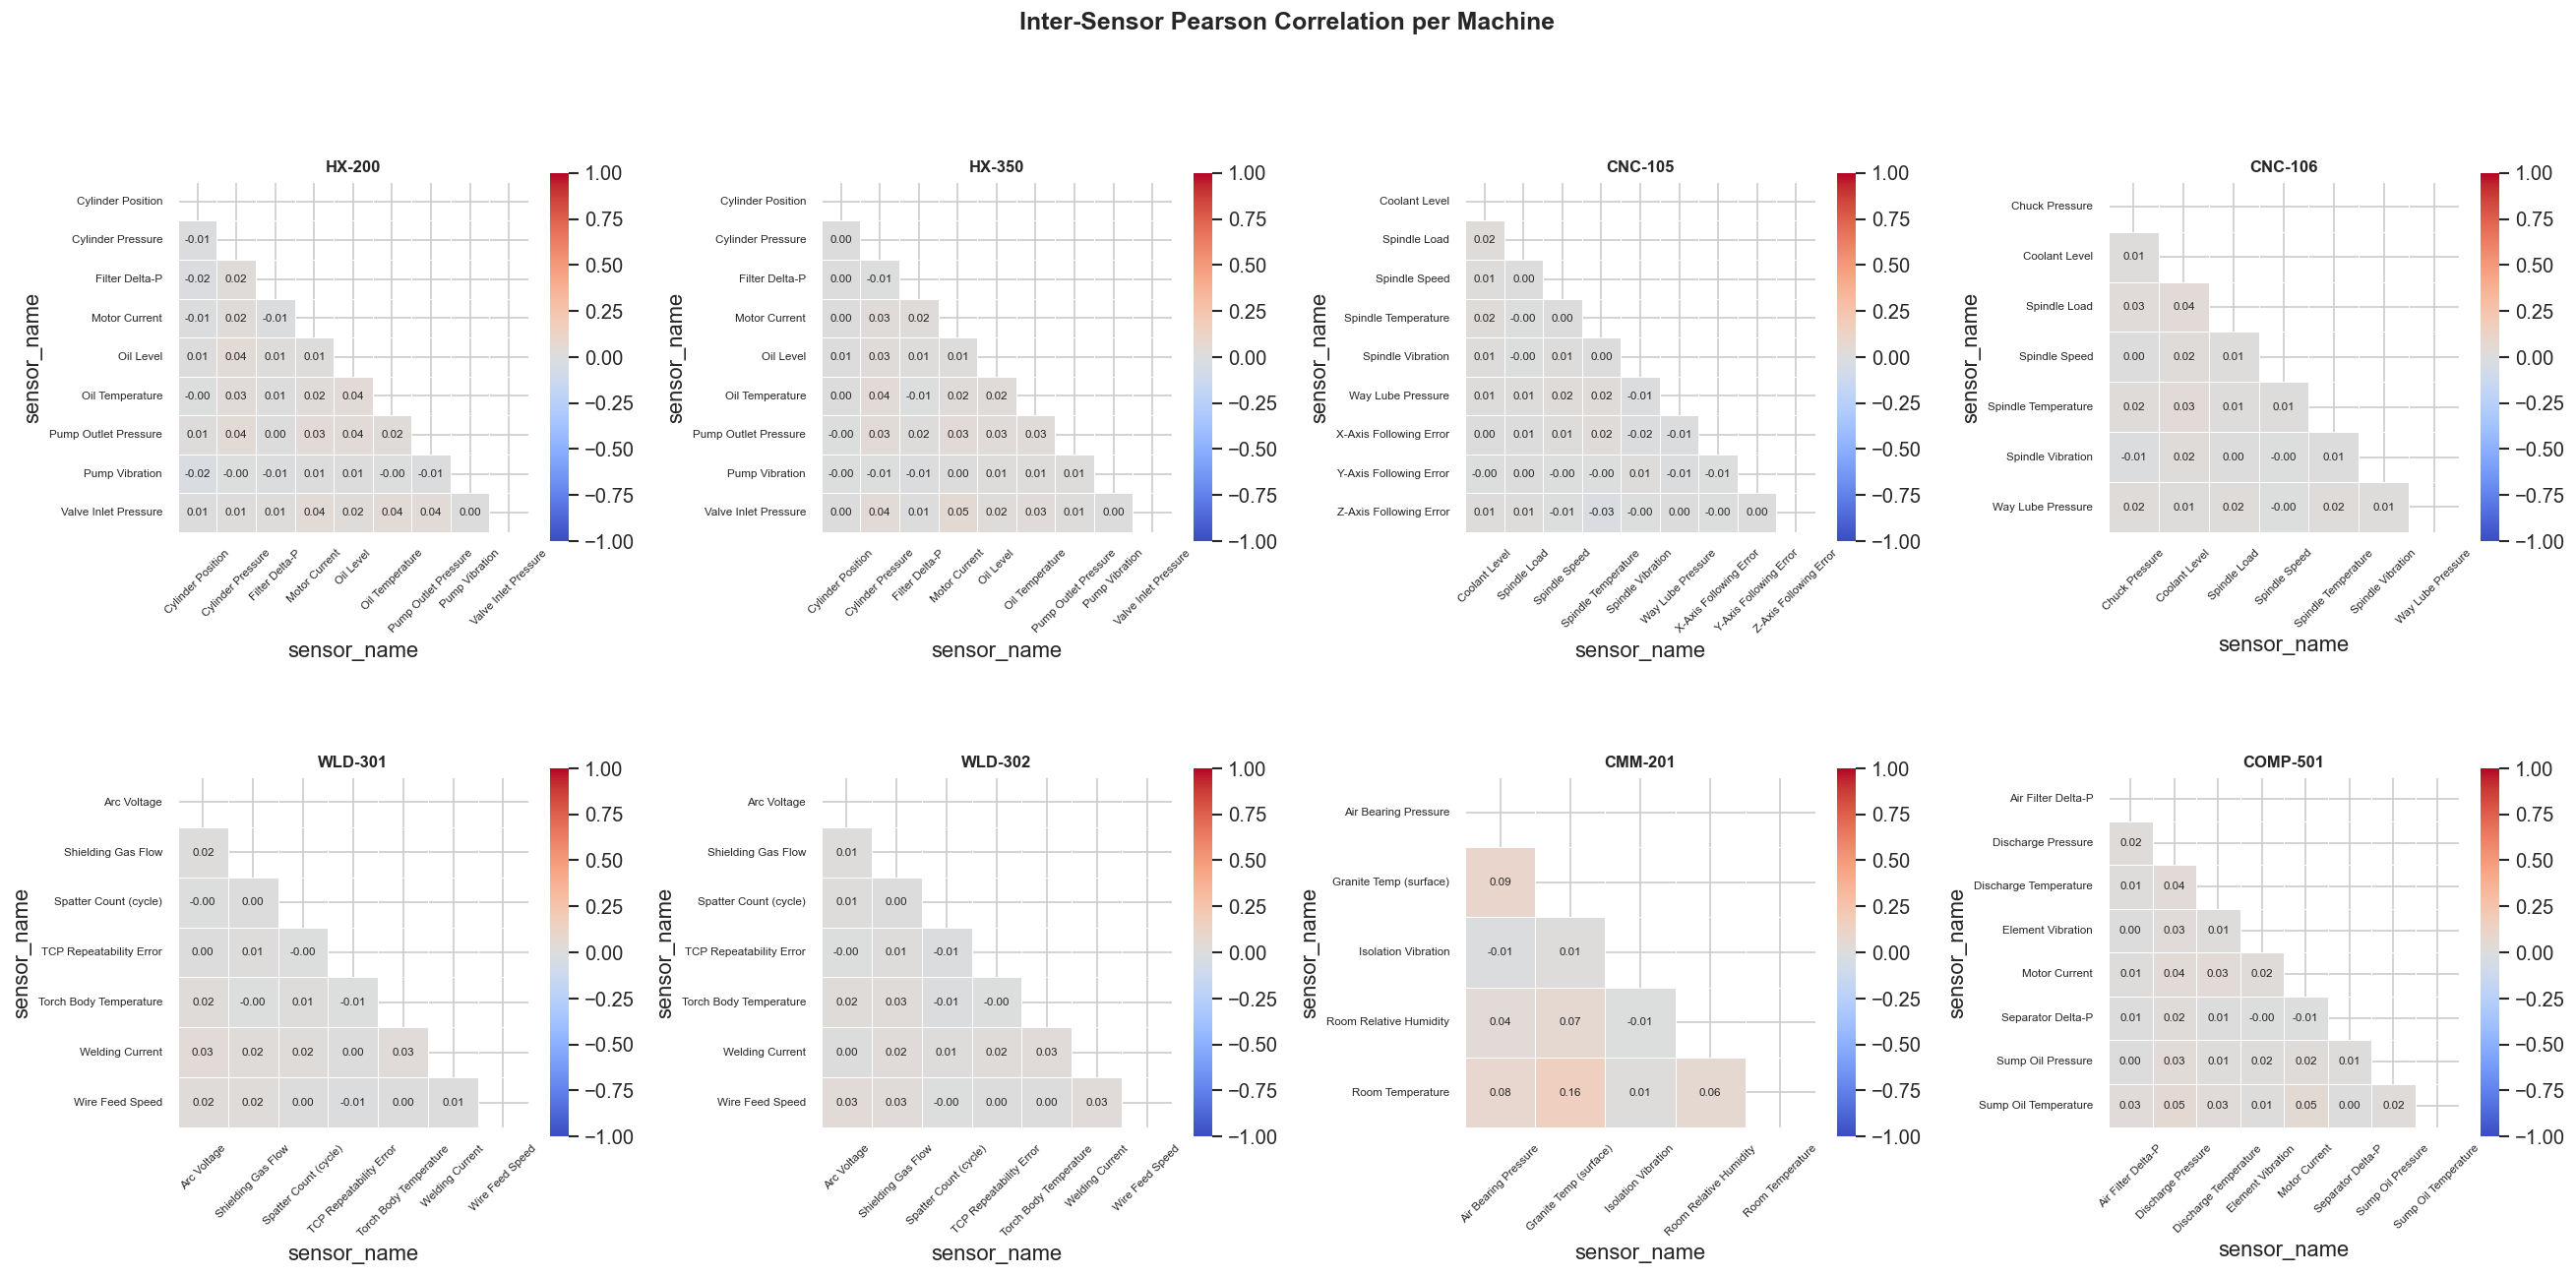

In [13]:
def plot_sensor_corr(machine_id, title, ax):
    sub = readings[readings['machine'] == machine_id]
    pivot = sub.pivot_table(index='timestamp', columns='sensor_name', values='value', aggfunc='mean')
    pivot = pivot.dropna(thresh=int(0.5 * len(pivot.columns)))
    if pivot.shape[1] < 2:
        ax.set_visible(False)
        return
    corr = pivot.corr(method='pearson')
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.3,
                annot=corr.shape[0] <= 10, fmt='.2f', annot_kws={'size': 7},
                cbar_kws={'shrink': 0.7})
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

machines = ['HX-200', 'HX-350', 'CNC-105', 'CNC-106', 'WLD-301', 'WLD-302', 'CMM-201', 'COMP-501']
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
for ax, mach in zip(axes.flatten(), machines):
    plot_sensor_corr(mach, mach, ax)

plt.suptitle('Inter-Sensor Pearson Correlation per Machine', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3 · Component Remaining Life

In [15]:
rl = pd.read_csv(DATA / 'remaining_life.csv',
                 parse_dates=['install_date', 'last_inspection', 'next_inspection'])
print(f'Shape: {rl.shape}')
print('\nCondition breakdown:')
print(rl['condition'].value_counts())
print('\nMachine types covered:')
print(rl['machine_type'].value_counts())
rl.head()

Shape: (128, 14)

Condition breakdown:
condition
GOOD           43
EXCELLENT      38
MONITOR        22
END_OF_LIFE    18
OVERDUE         7
Name: count, dtype: int64

Machine types covered:
machine_type
hydraulic_press      32
injection_molding    26
welding_robot        22
cnc_machining        14
compressor           12
cnc_turning          11
metrology            11
Name: count, dtype: int64


,component_id,component_name,machine,machine_type,install_date,expected_life_hours,current_hours,remaining_hours,remaining_pct,condition,unit_cost_eur,last_inspection,next_inspection,notes
0,HX-200-PUMP,Hydraulic Pump,HX-200,hydraulic_press,2024-10-17,20000,2152.0,260.0,1.3,END_OF_LIFE,8200,2024-12-13,2025-03-04,1.3% life remaining (260h). Replace at next op...
1,HX-200-CYL-SEAL,Cylinder Seal Kit,HX-200,hydraulic_press,2024-10-17,8000,2152.0,336.0,4.2,END_OF_LIFE,1200,2025-01-06,2025-03-18,4.2% life remaining (336h). Replace at next op...
2,HX-200-CYL-BORE,Cylinder Bore,HX-200,hydraulic_press,2024-10-17,60000,2152.0,49500.0,82.5,EXCELLENT,15000,2024-12-18,2025-02-04,82.5% life remaining. Recently replaced or low...
3,HX-200-FILTER,Hydraulic Filter Element,HX-200,hydraulic_press,2024-12-07,1000,930.0,70.0,7.0,MONITOR,85,2024-12-04,2025-03-12,"7.0% life remaining. Monitor closely, plan rep..."
4,HX-200-HOSE,High-Pressure Hose Set,HX-200,hydraulic_press,2024-10-17,35000,2152.0,24430.0,69.8,EXCELLENT,950,2025-01-08,2025-03-25,69.8% life remaining. Recently replaced or low...


### 3.1 · Component Condition Overview

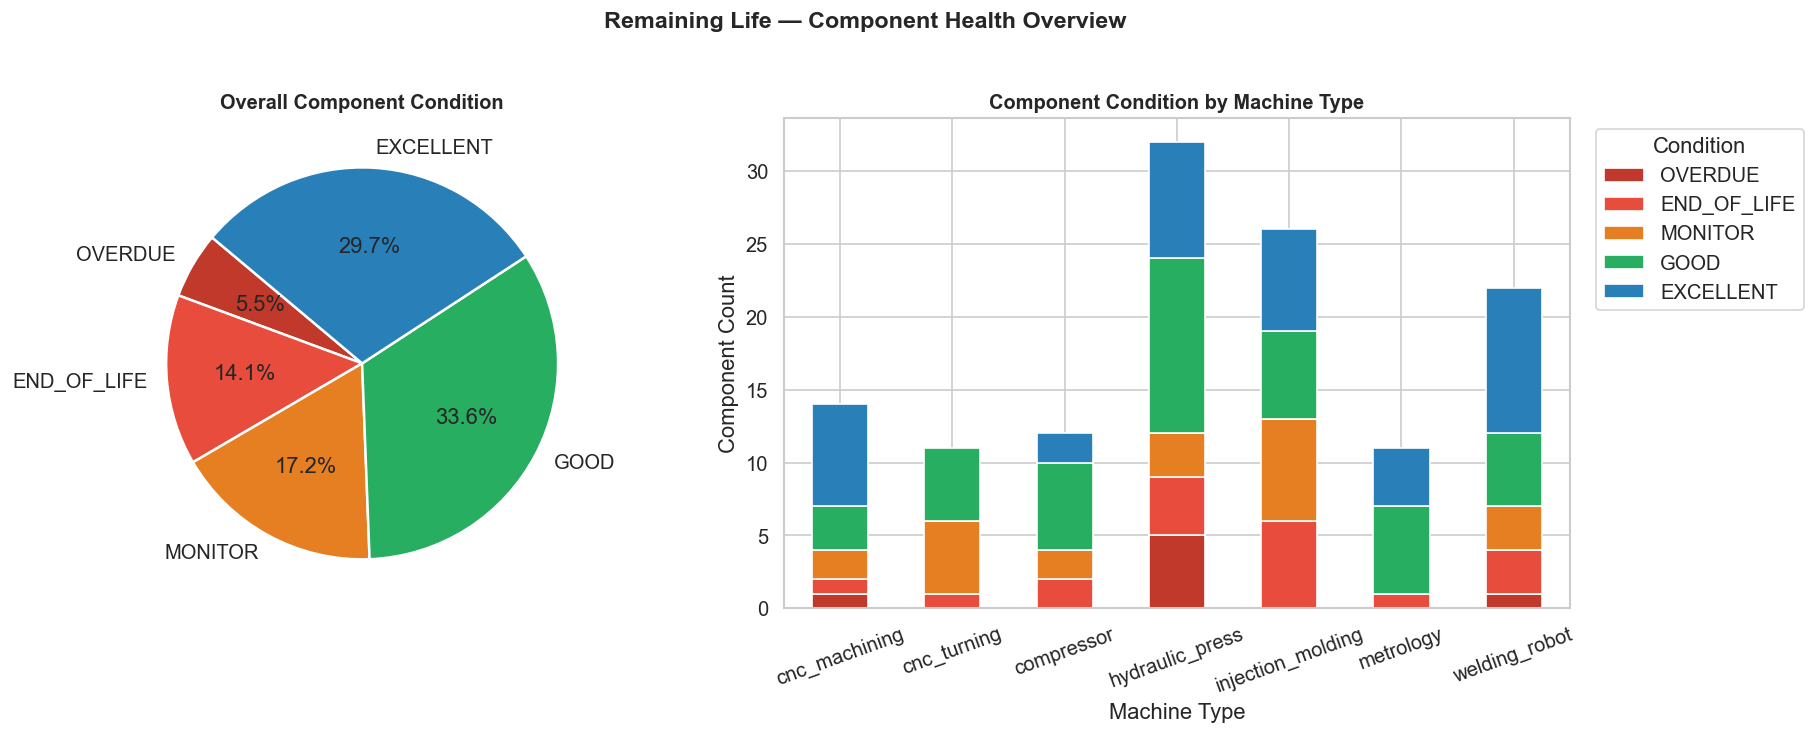

In [16]:
condition_order = ['OVERDUE', 'END_OF_LIFE', 'MONITOR', 'GOOD', 'EXCELLENT']
condition_colors = {
    'OVERDUE': '#c0392b', 'END_OF_LIFE': '#e74c3c',
    'MONITOR': '#e67e22', 'GOOD': '#27ae60', 'EXCELLENT': '#2980b9'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cond_counts = rl['condition'].value_counts().reindex(condition_order).dropna()
pie_colors = [condition_colors[c] for c in cond_counts.index]
axes[0].pie(cond_counts.values, labels=cond_counts.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Overall Component Condition', fontsize=12, fontweight='bold')

ct_pivot = rl.groupby(['machine_type', 'condition']).size().unstack(fill_value=0)
present_order = [c for c in condition_order if c in ct_pivot.columns]
ct_pivot[present_order].plot(kind='bar', stacked=True, ax=axes[1],
                              color=[condition_colors[c] for c in present_order],
                              edgecolor='white')
axes[1].set_xlabel('Machine Type')
axes[1].set_ylabel('Component Count')
axes[1].set_title('Component Condition by Machine Type', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Condition', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle('Remaining Life — Component Health Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.2 · Remaining Life % Distribution & Critical Components

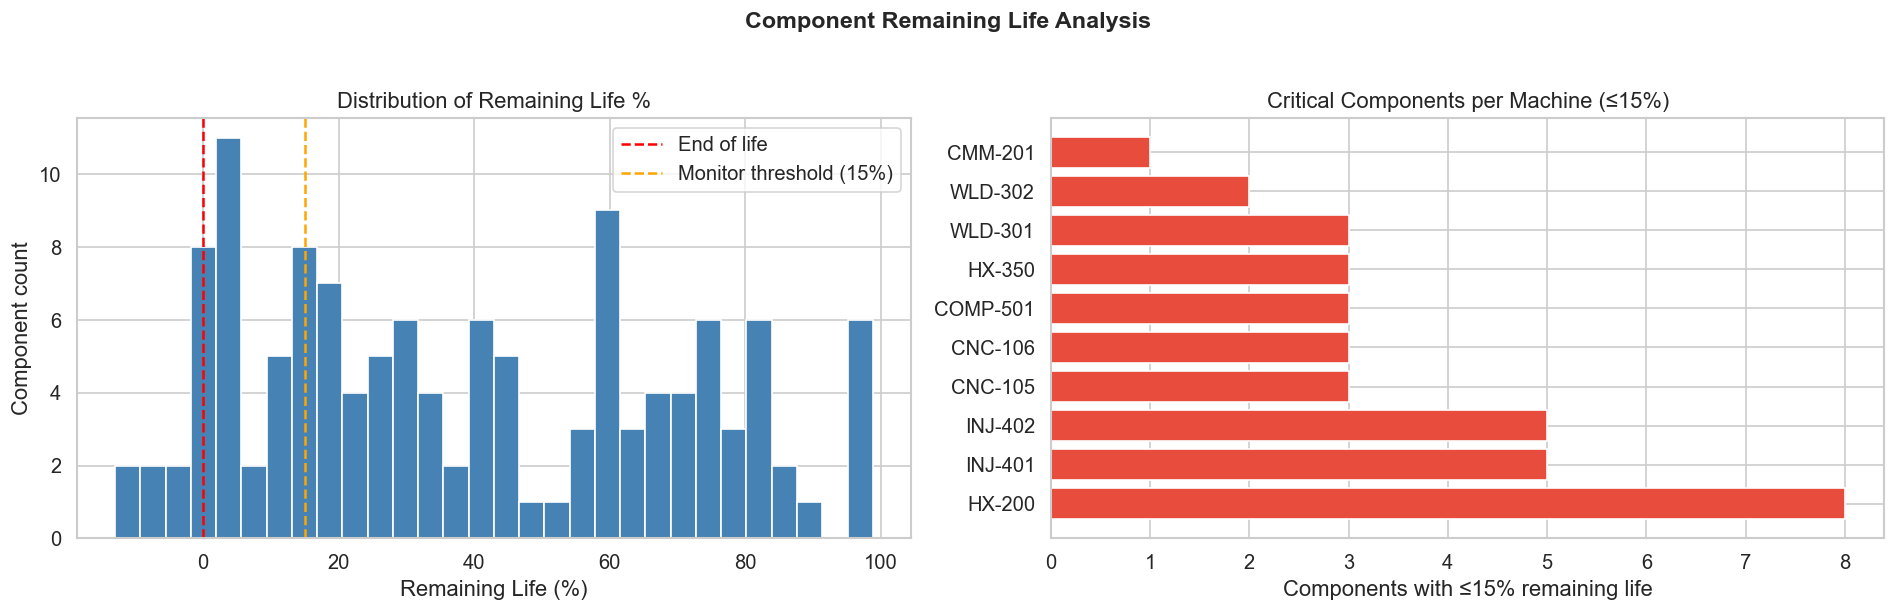


Critical components (≤15% remaining): 36
      component_id            component_name  machine  remaining_pct   condition
       HX-200-PUMP            Hydraulic Pump   HX-200            1.3 END_OF_LIFE
   HX-200-CYL-SEAL         Cylinder Seal Kit   HX-200            4.2 END_OF_LIFE
     HX-200-FILTER  Hydraulic Filter Element   HX-200            7.0     MONITOR
      HX-200-SOL-B           Solenoid Coil B   HX-200            0.0     OVERDUE
      HX-200-ACCUM       Accumulator Bladder   HX-200            0.5 END_OF_LIFE
    HX-200-BEARING          Pump Bearing Set   HX-200          -10.6     OVERDUE
     HX-200-PS-OUT    Pressure Sensor outlet   HX-200           -9.0     OVERDUE
        HX-200-PRV     Pressure Relief Valve   HX-200           -2.3     OVERDUE
     HX-350-FILTER  Hydraulic Filter Element   HX-350           13.8     MONITOR
      HX-350-GUIDE         Guide Bushing Set   HX-350          -13.0     OVERDUE
        HX-350-OIL   Hydraulic Oil ISO VG 46   HX-350            2.

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(rl['remaining_pct'].clip(-20, 110), bins=30,
             color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='End of life')
axes[0].axvline(15, color='orange', linestyle='--', label='Monitor threshold (15%)')
axes[0].set_xlabel('Remaining Life (%)')
axes[0].set_ylabel('Component count')
axes[0].set_title('Distribution of Remaining Life %')
axes[0].legend()

critical = rl[rl['remaining_pct'] <= 15].copy()
critical_by_machine = critical.groupby('machine').size().sort_values(ascending=False)
axes[1].barh(critical_by_machine.index, critical_by_machine.values,
             color='#e74c3c')
axes[1].set_xlabel('Components with ≤15% remaining life')
axes[1].set_title('Critical Components per Machine (≤15%)')

plt.suptitle('Component Remaining Life Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nCritical components (≤15% remaining): {len(critical)}')
print(critical[['component_id','component_name','machine','remaining_pct','condition']].to_string(index=False))

### 3.3 · Urgent Replacement Cost (OVERDUE + END_OF_LIFE)

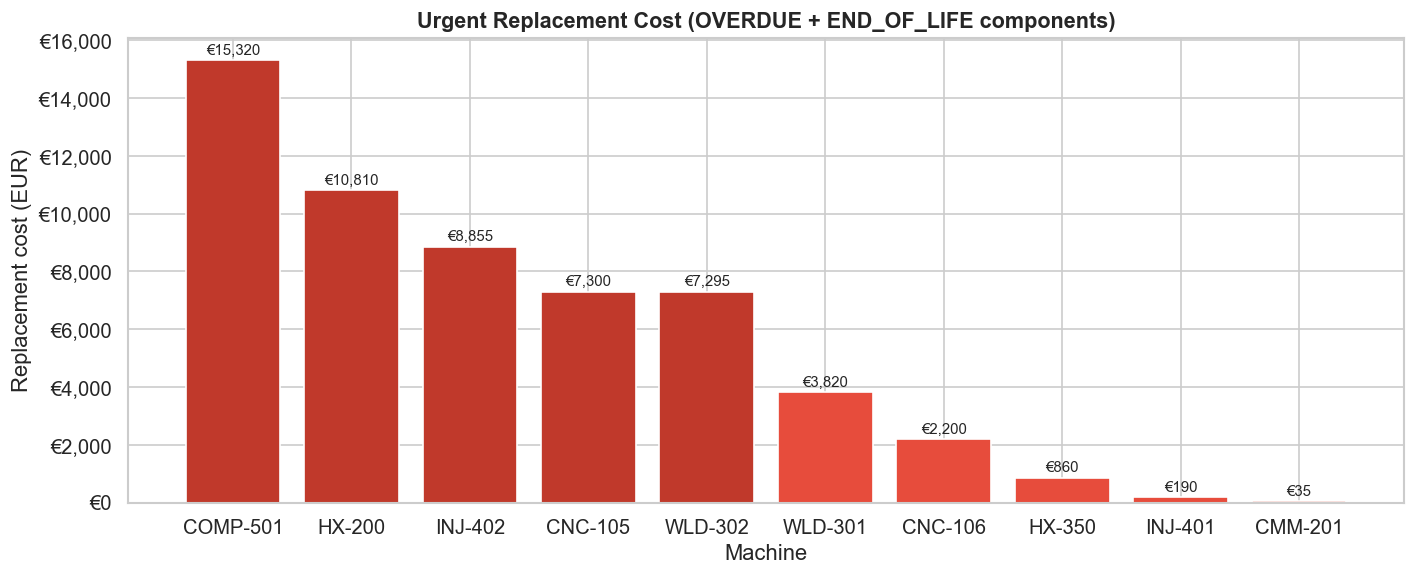

Total urgent replacement cost: €56,685
Machines affected             : 10


In [18]:
urgent = rl[rl['condition'].isin(['OVERDUE', 'END_OF_LIFE'])].copy()
urgent_cost = urgent.groupby('machine')['unit_cost_eur'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(urgent_cost.index, urgent_cost.values,
              color=['#c0392b' if v > 5000 else '#e74c3c' for v in urgent_cost.values],
              edgecolor='white')
ax.set_xlabel('Machine')
ax.set_ylabel('Replacement cost (EUR)')
ax.set_title('Urgent Replacement Cost (OVERDUE + END_OF_LIFE components)', fontsize=13, fontweight='bold')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'\u20ac{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'\u20ac{x:,.0f}'))
plt.tight_layout()
plt.show()

print(f'Total urgent replacement cost: \u20ac{urgent["unit_cost_eur"].sum():,.0f}')
print(f'Machines affected             : {urgent["machine"].nunique()}')

### 3.4 · Remaining Life vs Expected Life

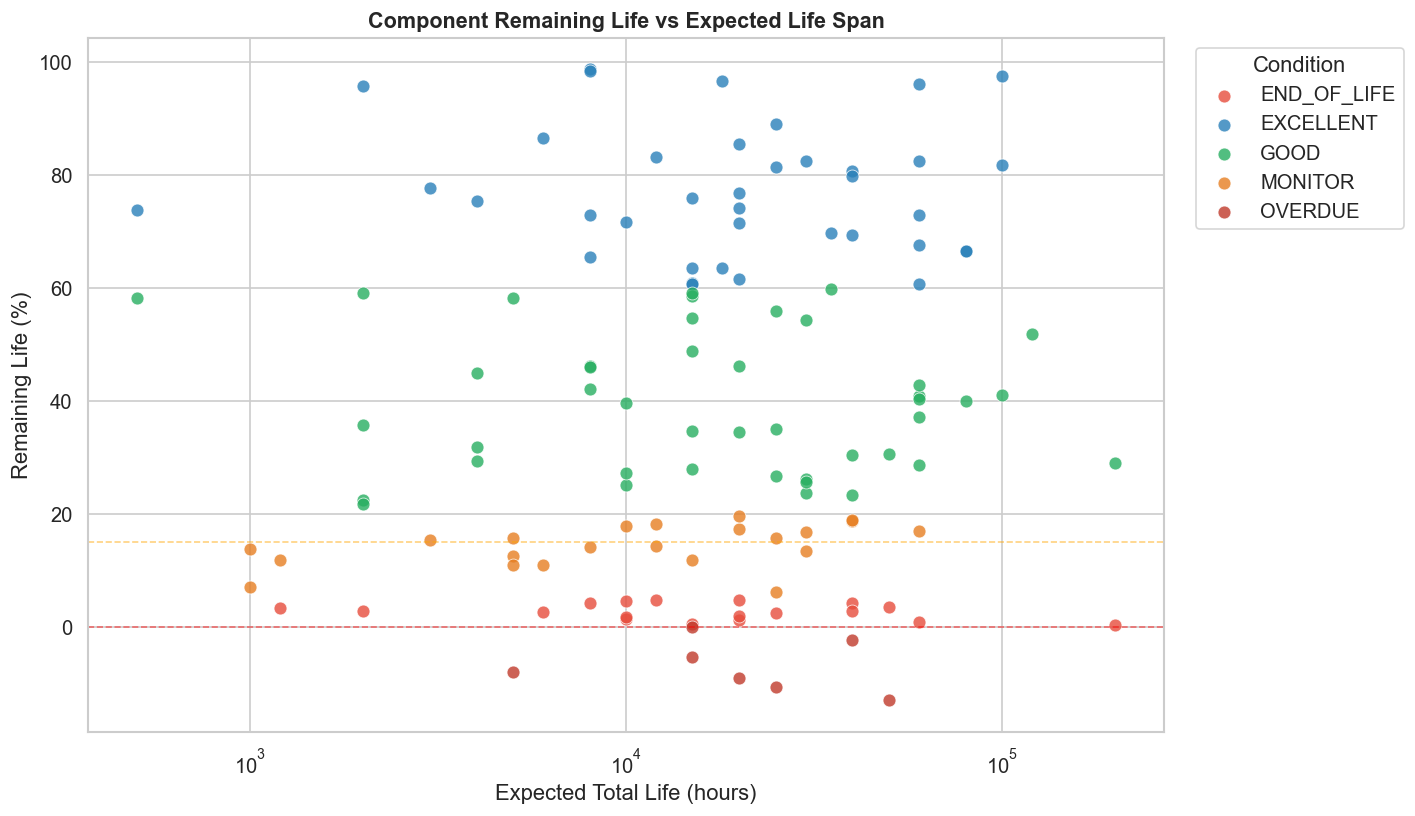

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))

for cond, grp in rl.groupby('condition'):
    ax.scatter(grp['expected_life_hours'], grp['remaining_pct'],
               label=cond, color=condition_colors.get(cond, 'grey'),
               alpha=0.8, s=60, edgecolors='white', linewidth=0.5)

ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(15, color='orange', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Expected Total Life (hours)')
ax.set_ylabel('Remaining Life (%)')
ax.set_title('Component Remaining Life vs Expected Life Span', fontsize=13, fontweight='bold')
ax.set_xscale('log')
ax.legend(title='Condition', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 4 · Interventions

In [20]:
intv = pd.read_csv(DATA / 'interventions.csv', parse_dates=['date_start', 'date_end'])
print(f'Shape: {intv.shape}')
print('\nIntervention types:')
print(intv['intervention_type'].value_counts())
print('\nPriority breakdown:')
print(intv['priority'].value_counts())
intv.head(3)

Shape: (2416, 18)

Intervention types:
intervention_type
CM    1933
PM     483
Name: count, dtype: int64

Priority breakdown:
priority
LOW         1117
WARNING      730
CRITICAL     569
Name: count, dtype: int64


,id,date_start,date_end,machine,machine_type,location,intervention_type,fault_code,fault_description,severity,subsystem,priority,technician,supervisor,duration_min,related_intervention,events,comments
0,INT-2022-0001,2022-01-01 07:43:00,2022-01-01 13:15:00,HX-350,Hydraulic Press,Shop A - Bay 3,CM,NaN,NaN,NaN,NaN,LOW,"Schmidt, K.","Pereira, A.",332,NaN,Unplanned inspection - Weekly PM for HX-350. N...,Unplanned corrective inspection - Weekly PM pe...
1,INT-2022-0002,2022-01-01 10:45:00,2022-01-01 13:07:00,CR-100,Cold Rolling Mill,Shop B - Line 1,CM,NaN,NaN,NaN,NaN,LOW,"Schmidt, K.","Chen, W.",142,NaN,Unplanned inspection - Annual Certification fo...,Unplanned corrective inspection - Annual Certi...
2,INT-2022-0003,2022-01-01 14:17:00,2022-01-01 14:34:00,CNC-750,CNC Machining Center,Shop C - Bay 4,CM,C-001,Tool length offset out of tolerance,WARNING,Tooling,WARNING,"Leclerc, B.","Moreau, L.",17,NaN,Tool length offset alarm C-001. Offset drift 7...,Symptom: tool offset drift 76.9mm. Probable ca...


### 4.1 · Monthly Intervention Volume by Type

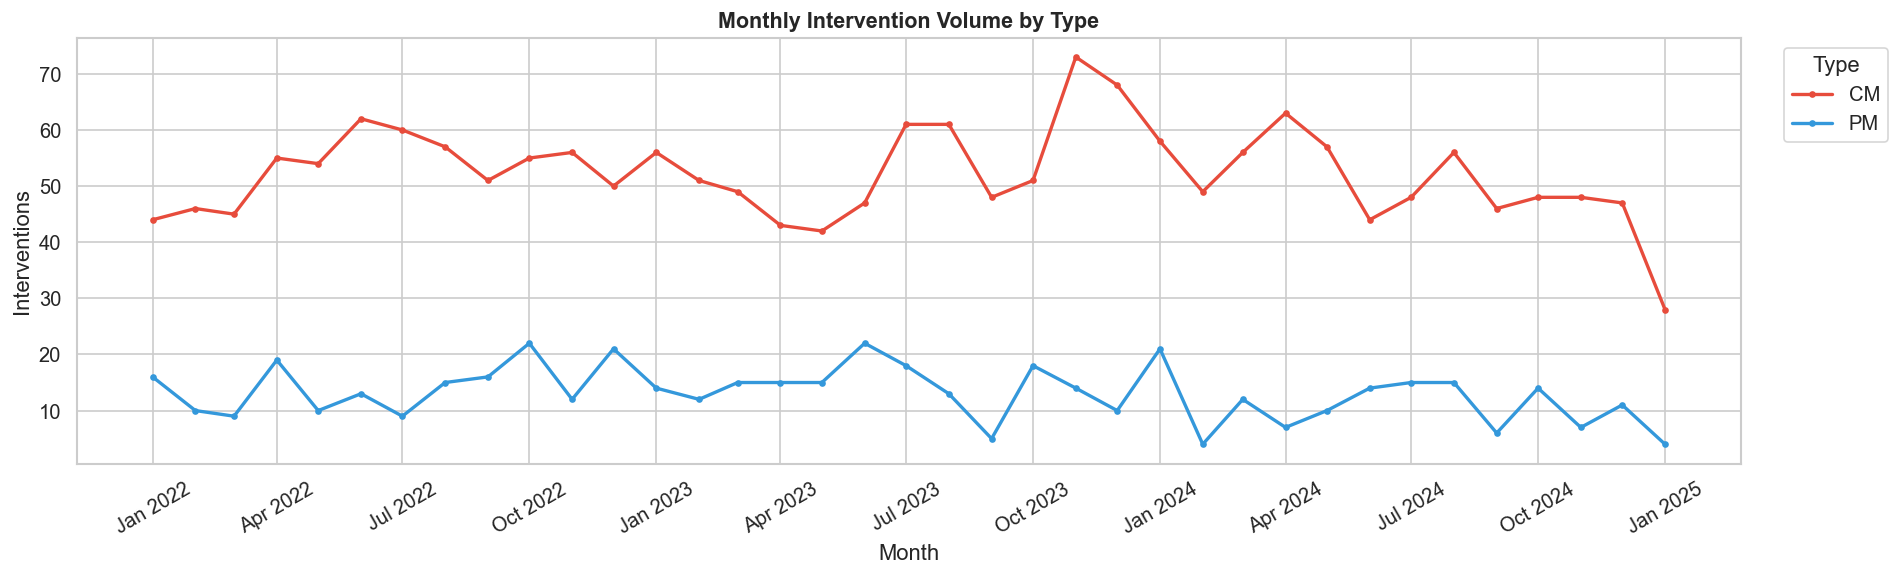

In [21]:
intv['year_month'] = intv['date_start'].dt.to_period('M')
monthly = intv.groupby(['year_month', 'intervention_type']).size().unstack(fill_value=0)
monthly.index = monthly.index.to_timestamp()

type_colors = {'CM': '#e74c3c', 'PM': '#3498db', 'PdM': '#2ecc71', 'EM': '#9b59b6'}

fig, ax = plt.subplots(figsize=(16, 5))
for col in monthly.columns:
    ax.plot(monthly.index, monthly[col], label=col,
            color=type_colors.get(col, 'grey'), linewidth=2, marker='o', markersize=3)

ax.set_xlabel('Month')
ax.set_ylabel('Interventions')
ax.set_title('Monthly Intervention Volume by Type', fontsize=13, fontweight='bold')
ax.legend(title='Type', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 4.2 · Intervention Type, Severity & Duration

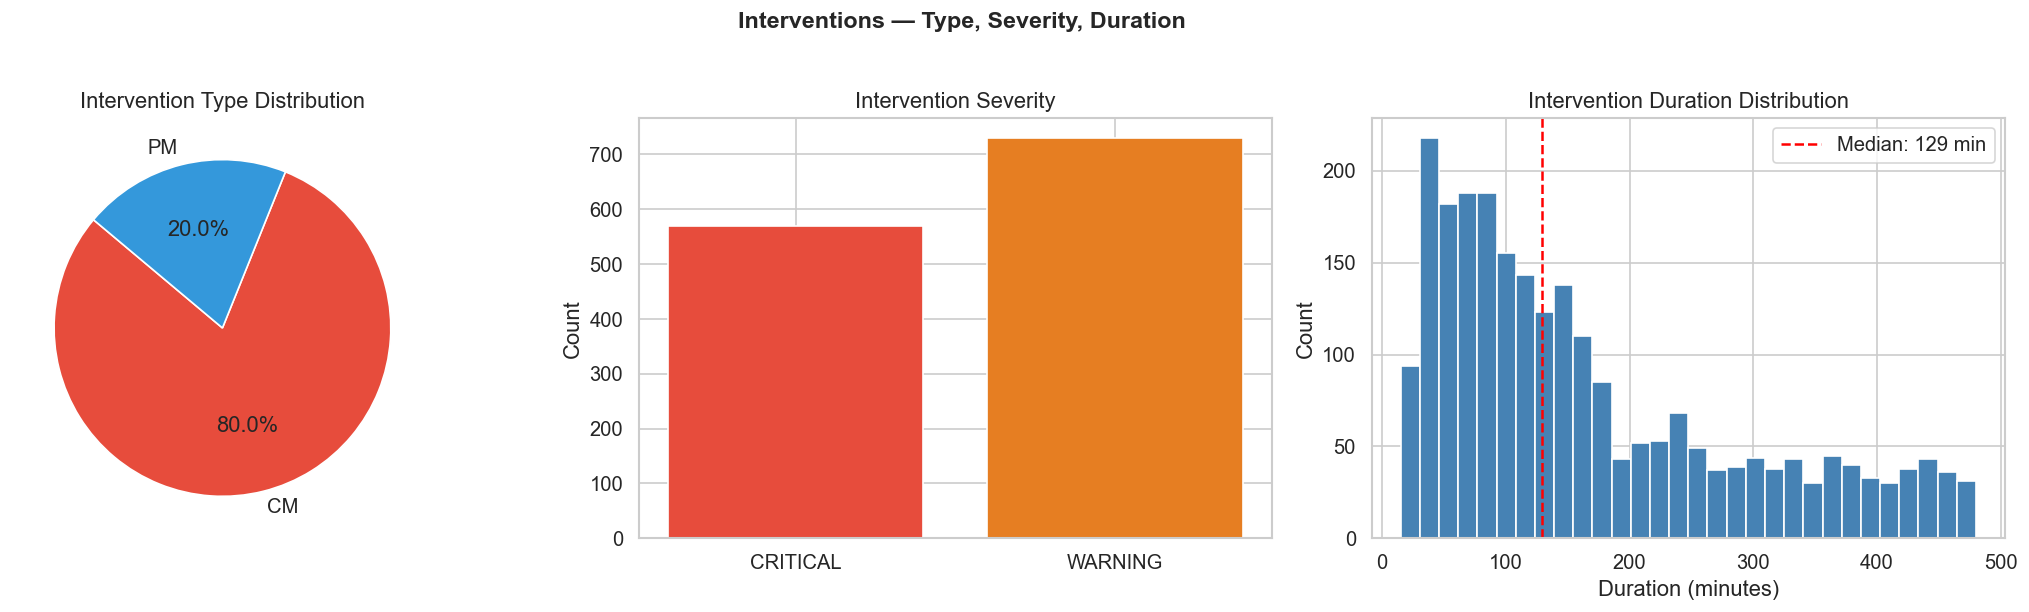

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

type_counts = intv['intervention_type'].value_counts()
axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=[type_colors.get(t, 'grey') for t in type_counts.index],
            startangle=140, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Intervention Type Distribution')

sev_order = ['CRITICAL', 'WARNING', 'LOW']
sev_colors = {'CRITICAL': '#e74c3c', 'WARNING': '#e67e22', 'LOW': '#27ae60'}
sev_counts = intv['severity'].value_counts().reindex(sev_order).dropna()
axes[1].bar(sev_counts.index, sev_counts.values,
            color=[sev_colors[s] for s in sev_counts.index], edgecolor='white')
axes[1].set_title('Intervention Severity')
axes[1].set_ylabel('Count')

axes[2].hist(intv['duration_min'].dropna().clip(0, 600), bins=30,
             color='steelblue', edgecolor='white')
axes[2].set_xlabel('Duration (minutes)')
axes[2].set_ylabel('Count')
axes[2].set_title('Intervention Duration Distribution')
axes[2].axvline(intv['duration_min'].median(), color='red', linestyle='--',
                label=f'Median: {intv["duration_min"].median():.0f} min')
axes[2].legend()

plt.suptitle('Interventions — Type, Severity, Duration', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.3 · Interventions per Machine by Type

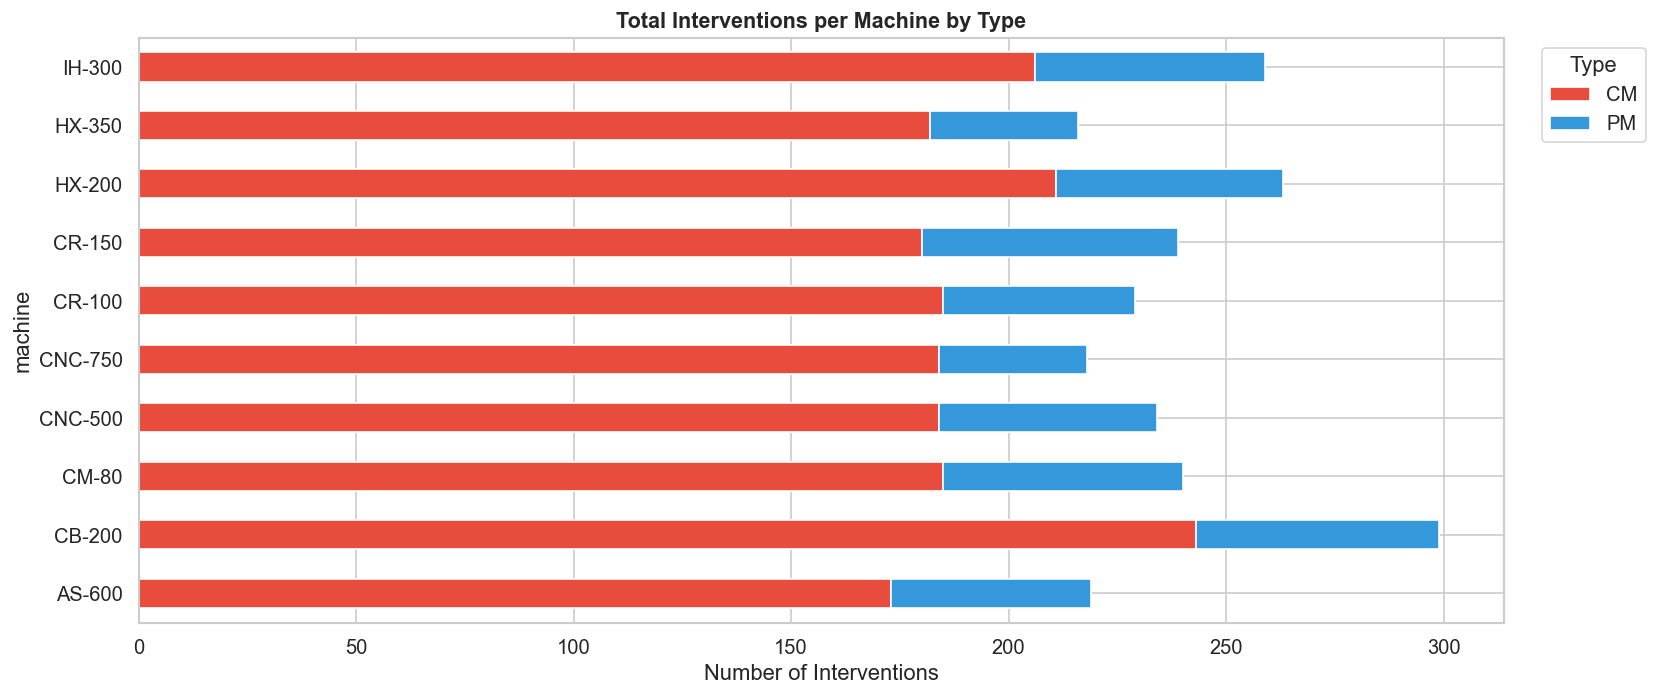

In [23]:
intv_by_machine = intv.groupby(['machine', 'intervention_type']).size().unstack(fill_value=0)
present_types = [t for t in ['CM', 'PM', 'PdM', 'EM'] if t in intv_by_machine.columns]
intv_by_machine = intv_by_machine[present_types]

fig, ax = plt.subplots(figsize=(14, 6))
intv_by_machine.plot(kind='barh', stacked=True, ax=ax,
                     color=[type_colors.get(t, 'grey') for t in present_types],
                     edgecolor='white')
ax.set_xlabel('Number of Interventions')
ax.set_title('Total Interventions per Machine by Type', fontsize=13, fontweight='bold')
ax.legend(title='Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.4 · MTBF & MTTR per Machine

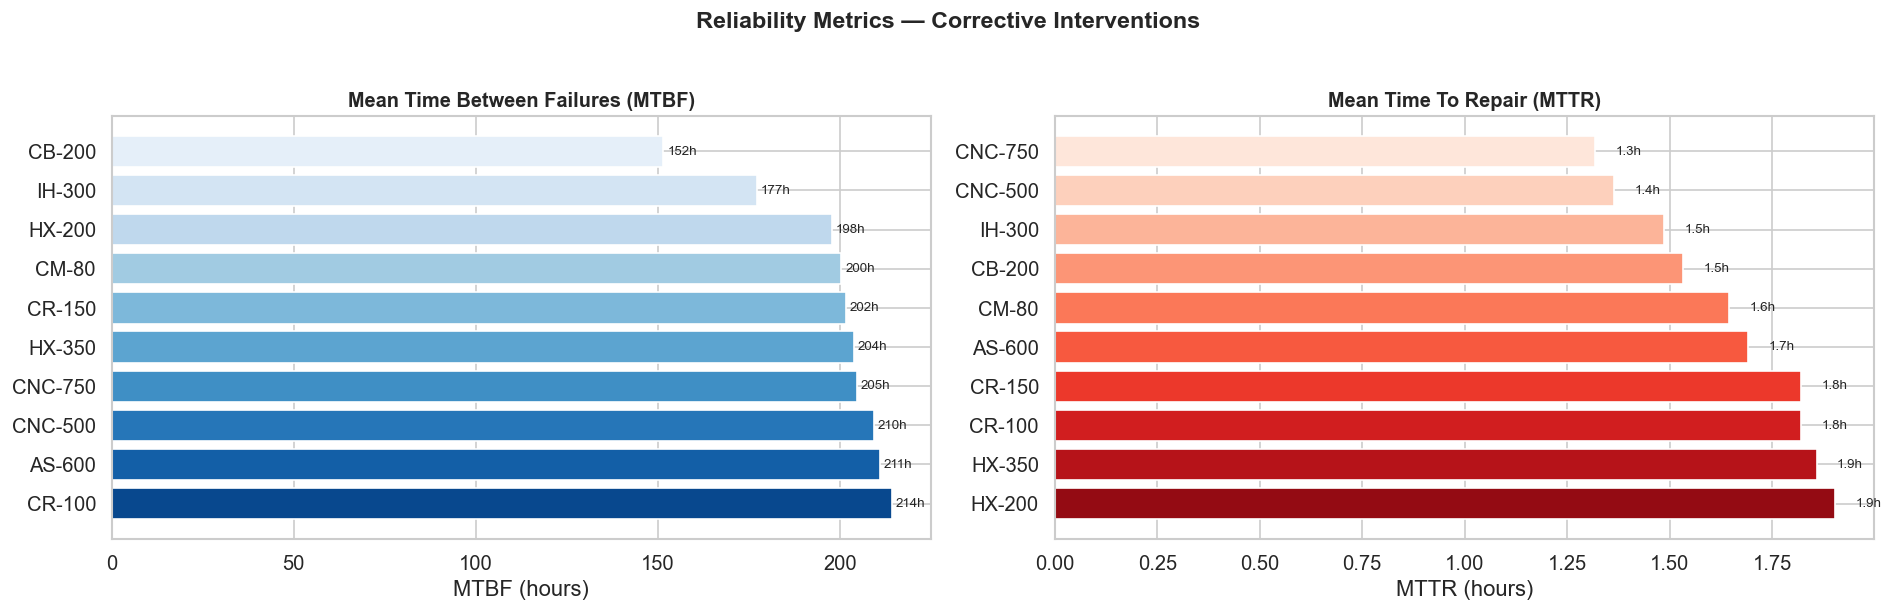

In [24]:
failures = intv[intv['intervention_type'] == 'CM'].dropna(subset=['fault_code']).copy()
failures = failures.sort_values('date_start')

mttr = failures.groupby('machine')['duration_min'].mean() / 60
mttr = mttr.sort_values(ascending=False).dropna()

def compute_mtbf(df):
    if len(df) < 2:
        return np.nan
    diffs = df['date_start'].sort_values().diff().dt.total_seconds() / 3600
    return diffs.mean()

mtbf = failures.groupby('machine').apply(compute_mtbf).sort_values(ascending=False).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(mtbf.index, mtbf.values, color=sns.color_palette('Blues_r', len(mtbf)))
axes[0].set_xlabel('MTBF (hours)')
axes[0].set_title('Mean Time Between Failures (MTBF)', fontsize=12, fontweight='bold')
for i, v in enumerate(mtbf.values):
    axes[0].text(v + 1, i, f'{v:.0f}h', va='center', fontsize=8)

axes[1].barh(mttr.index, mttr.values, color=sns.color_palette('Reds_r', len(mttr)))
axes[1].set_xlabel('MTTR (hours)')
axes[1].set_title('Mean Time To Repair (MTTR)', fontsize=12, fontweight='bold')
for i, v in enumerate(mttr.values):
    axes[1].text(v + 0.05, i, f'{v:.1f}h', va='center', fontsize=8)

plt.suptitle('Reliability Metrics — Corrective Interventions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.5 · Top Fault Codes & Most Active Technicians

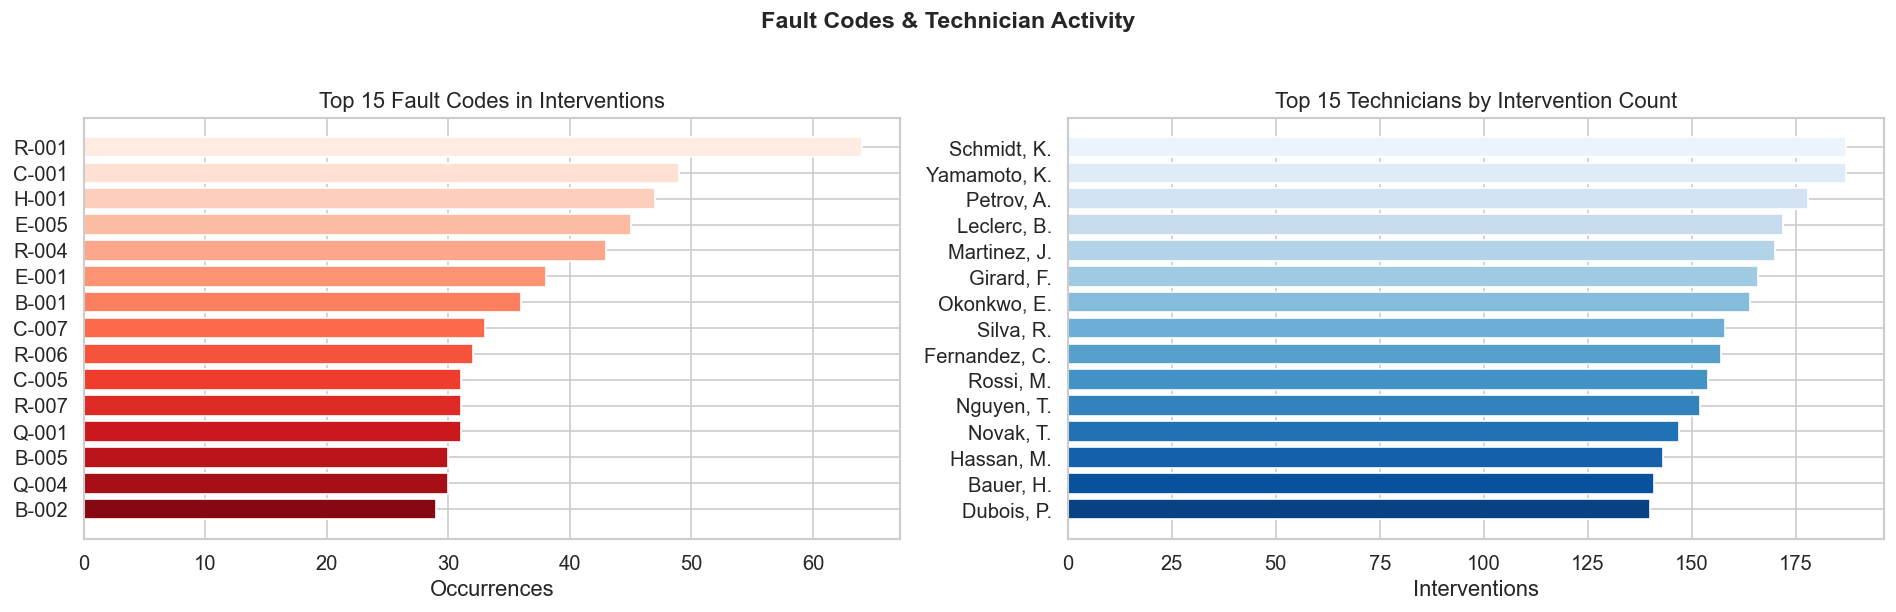

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fc_counts = intv['fault_code'].dropna().value_counts().head(15)
axes[0].barh(fc_counts.index[::-1], fc_counts.values[::-1],
             color=sns.color_palette('Reds_r', len(fc_counts)))
axes[0].set_xlabel('Occurrences')
axes[0].set_title('Top 15 Fault Codes in Interventions')

tech_counts = intv['technician'].value_counts().head(15)
axes[1].barh(tech_counts.index[::-1], tech_counts.values[::-1],
             color=sns.color_palette('Blues_r', len(tech_counts)))
axes[1].set_xlabel('Interventions')
axes[1].set_title('Top 15 Technicians by Intervention Count')

plt.suptitle('Fault Codes & Technician Activity', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.6 · Intervention Heatmap — Day of Week × Hour

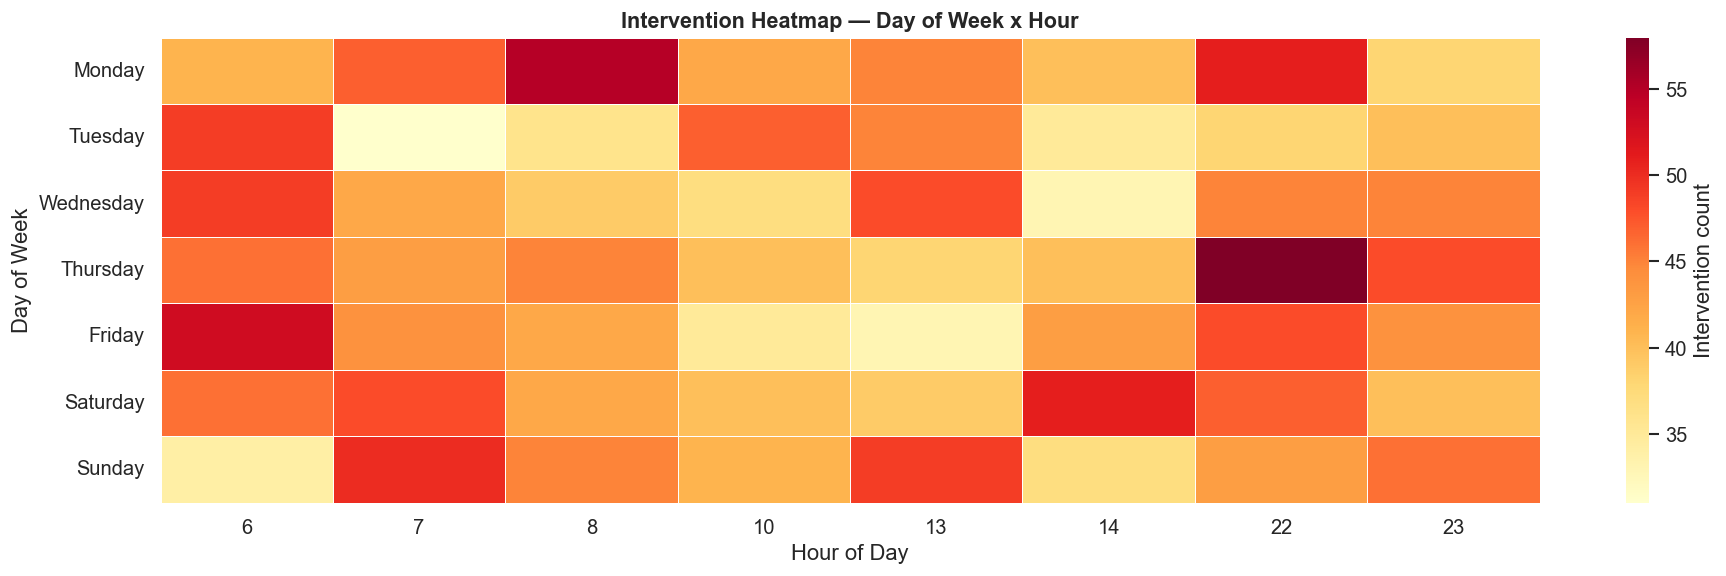

In [26]:
intv['dow'] = intv['date_start'].dt.day_name()
intv['hour'] = intv['date_start'].dt.hour

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heat_data = intv.groupby(['dow', 'hour']).size().unstack(fill_value=0)
heat_data = heat_data.reindex(dow_order)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heat_data, ax=ax, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Intervention count'})
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
ax.set_title('Intervention Heatmap — Day of Week x Hour', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5 · Cross-Dataset Analysis

### 5.1 · Sensor Alert Rate vs Intervention Frequency per Machine

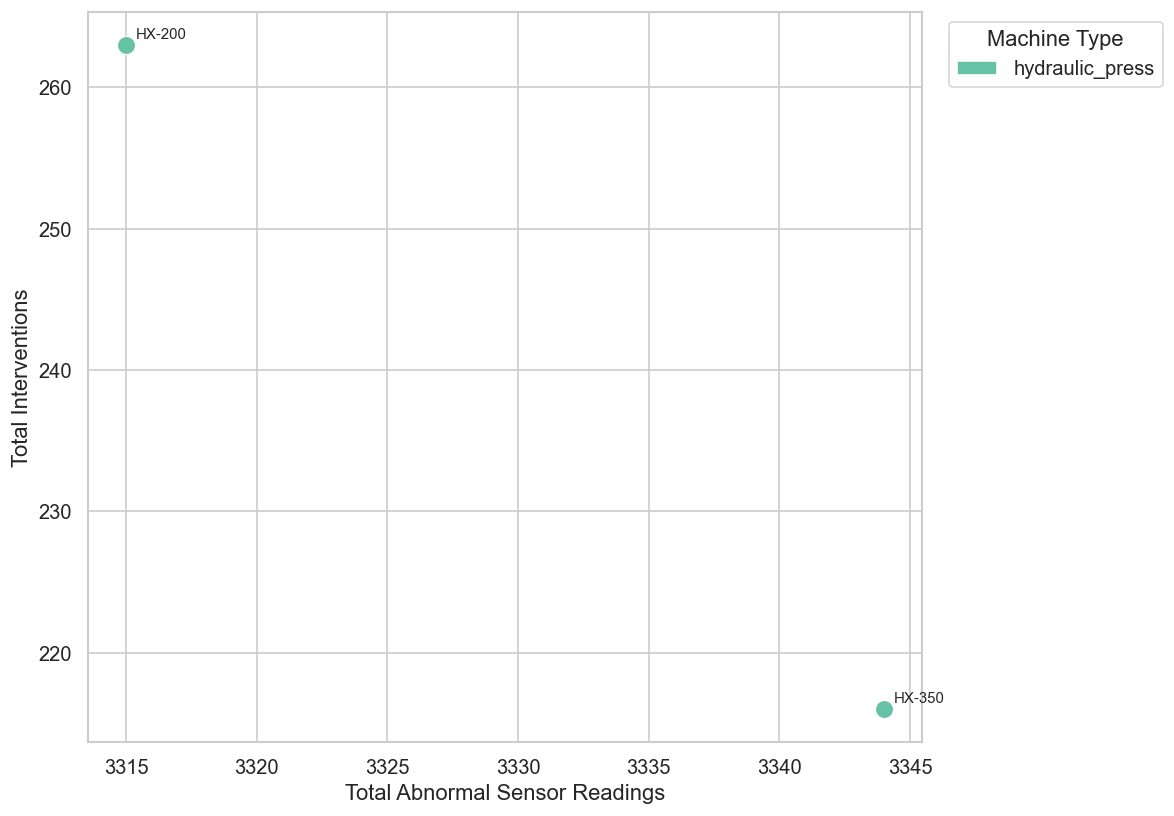

In [27]:
from matplotlib.patches import Patch

alert_rate = (
    readings[readings['status'].isin(['WARNING', 'FAULT', 'CRITICAL'])]
    .groupby('machine').size().rename('alert_count')
)
intv_rate = intv.groupby('machine').size().rename('intervention_count')
cross = pd.concat([alert_rate, intv_rate], axis=1).dropna()
cross['machine_type'] = cross.index.map(dict(zip(catalog['machine'], catalog['machine_type'])))

palette = sns.color_palette('Set2', cross['machine_type'].nunique())
type_color_map = dict(zip(cross['machine_type'].unique(), palette))

fig, ax = plt.subplots(figsize=(10, 7))
for _, row in cross.iterrows():
    color = type_color_map.get(row['machine_type'], 'grey')
    ax.scatter(row['alert_count'], row['intervention_count'],
               color=color, s=120, edgecolors='white', linewidth=0.8, zorder=5)
    ax.annotate(row.name, (row['alert_count'], row['intervention_count']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

if len(cross) > 2:
    r = cross[['alert_count', 'intervention_count']].corr().iloc[0, 1]
    ax.set_title(f'Sensor Alerts vs Interventions per Machine  (r = {r:.2f})',
                 fontsize=13, fontweight='bold')

legend_elements = [Patch(facecolor=c, label=t) for t, c in type_color_map.items()]
ax.legend(handles=legend_elements, title='Machine Type', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xlabel('Total Abnormal Sensor Readings')
ax.set_ylabel('Total Interventions')
plt.tight_layout()
plt.show()

### 5.2 · Machine Health Score vs Intervention History

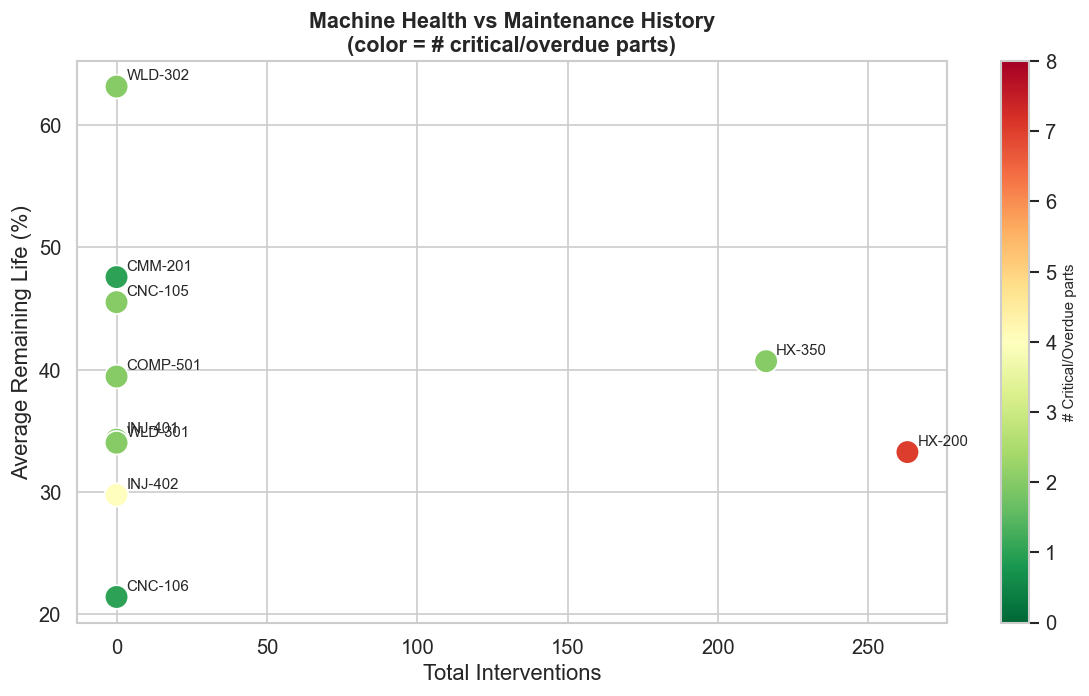

In [28]:
avg_remaining = rl.groupby('machine')['remaining_pct'].mean().rename('avg_remaining_pct')
intv_count = intv.groupby('machine').size().rename('intervention_count')
overdue_count = rl[rl['condition'].isin(['OVERDUE', 'END_OF_LIFE'])].groupby('machine').size().rename('critical_parts')

health = pd.concat([avg_remaining, intv_count, overdue_count], axis=1).dropna(subset=['avg_remaining_pct'])
health['intervention_count'] = health['intervention_count'].fillna(0)
health['critical_parts'] = health['critical_parts'].fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    health['intervention_count'], health['avg_remaining_pct'],
    c=health['critical_parts'], cmap='RdYlGn_r',
    s=200, edgecolors='white', linewidth=1, zorder=5, vmin=0, vmax=8
)
for machine, row in health.iterrows():
    ax.annotate(machine, (row['intervention_count'], row['avg_remaining_pct']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('# Critical/Overdue parts', fontsize=9)
ax.set_xlabel('Total Interventions')
ax.set_ylabel('Average Remaining Life (%)')
ax.set_title('Machine Health vs Maintenance History\n(color = # critical/overdue parts)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 · Sensor Warning Rate vs Critical Parts Count

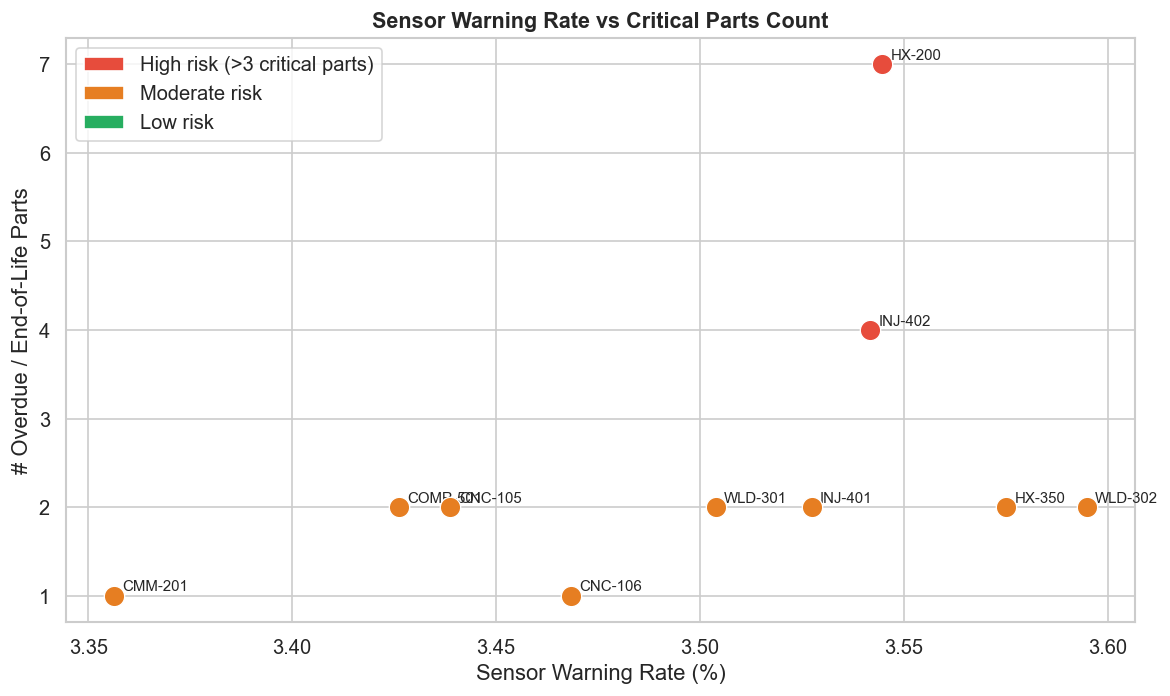

In [29]:
total_readings = readings.groupby('machine').size().rename('total_readings')
warn_readings = readings[readings['status'] != 'NORMAL'].groupby('machine').size().rename('warn_readings')
warn_rate = (warn_readings / total_readings * 100).rename('warn_rate_pct')

merged = pd.concat([warn_rate, overdue_count], axis=1).dropna(subset=['warn_rate_pct'])
merged['critical_parts'] = merged['critical_parts'].fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
for machine, row in merged.iterrows():
    color = '#e74c3c' if row['critical_parts'] > 3 else ('#e67e22' if row['critical_parts'] > 0 else '#27ae60')
    ax.scatter(row['warn_rate_pct'], row['critical_parts'],
               color=color, s=150, edgecolors='white', linewidth=0.8, zorder=5)
    ax.annotate(machine, (row['warn_rate_pct'], row['critical_parts']),
                textcoords='offset points', xytext=(5, 3), fontsize=9)

ax.set_xlabel('Sensor Warning Rate (%)')
ax.set_ylabel('# Overdue / End-of-Life Parts')
ax.set_title('Sensor Warning Rate vs Critical Parts Count', fontsize=13, fontweight='bold')

legend_elements = [
    Patch(facecolor='#e74c3c', label='High risk (>3 critical parts)'),
    Patch(facecolor='#e67e22', label='Moderate risk'),
    Patch(facecolor='#27ae60', label='Low risk'),
]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

---
## 6 · Printed Summary Report

In [30]:
print('=' * 70)
print('  HEPHAESTUS — DATA EXPLORATION SUMMARY REPORT')
print('=' * 70)

print('\n--- DATASET OVERVIEW ---')
print(f'  Sensor catalog  : {len(catalog)} sensors | {catalog["machine"].nunique()} machines')
print(f'  Sensor readings : {len(readings):,} rows | '
      f'{readings["timestamp"].min().date()} to {readings["timestamp"].max().date()}')
print(f'  Component health: {len(rl)} components tracked')
print(f'  Interventions   : {len(intv):,} events | '
      f'{intv["date_start"].min().date()} to {intv["date_start"].max().date()}')

print('\n--- MACHINE FLEET ---')
for mt, grp in catalog.groupby('machine_type'):
    print(f'  {mt:<25}: {list(grp["machine"].unique())}')

print('\n--- SENSOR HEALTH ---')
total = len(readings)
for st in ['NORMAL', 'WARNING', 'FAULT', 'CRITICAL']:
    cnt = (readings['status'] == st).sum()
    print(f'  {st:<12}: {cnt:>9,}  ({cnt/total*100:.2f}%)')

print('\n--- COMPONENT CONDITION ---')
for cond in condition_order:
    cnt = (rl['condition'] == cond).sum()
    print(f'  {cond:<15}: {cnt} components')
urgent_cost_total = rl[rl['condition'].isin(['OVERDUE','END_OF_LIFE'])]['unit_cost_eur'].sum()
print(f'  Urgent replacement budget: \u20ac{urgent_cost_total:,.0f}')

print('\n--- MAINTENANCE HISTORY ---')
for t, grp in intv.groupby('intervention_type'):
    print(f'  {t}: {len(grp)} events | avg duration {grp["duration_min"].mean():.0f} min')
print(f'  Most active machine : {intv["machine"].value_counts().idxmax()} '
      f'({intv["machine"].value_counts().max()} interventions)')
top_fault = intv["fault_code"].value_counts()
if len(top_fault):
    print(f'  Top fault code      : {top_fault.idxmax()} ({top_fault.max()} occurrences)')

print('\n--- KEY RISKS ---')
overdue_m = rl[rl['condition'] == 'OVERDUE']['machine'].unique()
eol_m = rl[rl['condition'] == 'END_OF_LIFE']['machine'].unique()
print(f'  OVERDUE components   : {list(overdue_m)}')
print(f'  END_OF_LIFE machines : {list(eol_m)}')
high_warn = warn_rate.sort_values(ascending=False).head(5)
print(f'  Highest warning rates: {list(high_warn.index)} ({list(high_warn.round(2))}%)')
print('\n' + '=' * 70)

  HEPHAESTUS — DATA EXPLORATION SUMMARY REPORT

--- DATASET OVERVIEW ---
  Sensor catalog  : 77 sensors | 10 machines
  Sensor readings : 800,035 rows | 2024-07-01 to 2024-12-18
  Component health: 128 components tracked
  Interventions   : 2,416 events | 2022-01-01 to 2025-01-14

--- MACHINE FLEET ---
  cnc_machining            : ['CNC-105']
  cnc_turning              : ['CNC-106']
  compressor               : ['COMP-501']
  hydraulic_press          : ['HX-200', 'HX-350']
  injection_molding        : ['INJ-401', 'INJ-402']
  metrology                : ['CMM-201']
  welding_robot            : ['WLD-301', 'WLD-302']

--- SENSOR HEALTH ---
  NORMAL      :   772,009  (96.50%)
  FAULT       :         0  (0.00%)
  CRITICAL    :     4,155  (0.52%)

--- COMPONENT CONDITION ---
  OVERDUE        : 7 components
  END_OF_LIFE    : 18 components
  MONITOR        : 22 components
  GOOD           : 43 components
  EXCELLENT      : 38 components
  Urgent replacement budget: €56,685

--- MAINTENANCE H

---
## 7 · Conclusions & Recommendations

### Data Quality
- All four CSV files are clean with no significant missing values in key columns.
- All 77 sensors are **active**, all sampled at **60-second intervals**.
- Sensor readings cover roughly **6 months** of continuous monitoring.
- Interventions span a **3-year** history (2022–2025) — a rich labelled dataset.

### Fleet at a Glance
| Machine type | Machines | Sensors | Notes |
|---|---|---|---|
| hydraulic_press | HX-200, HX-350 | 9 each | Bay A - Press Shop |
| cnc_machining | CNC-105 | 9 | Bay B - Machining |
| cnc_turning | CNC-106 | 7 | Bay B - Machining |
| welding_robot | WLD-301, WLD-302 | 7 each | Bay C - Welding |
| metrology | CMM-201 | 5 | Bay D - Quality Lab |
| injection_molding | INJ-401, INJ-402 | 8 each | Bay E - Molding |
| compressor | COMP-501 | 8 | Utilities Room |

### Sensor Health
- **>98% NORMAL** — operations are generally stable.
- The ~2% abnormal readings are the primary signal for predictive maintenance.
- Fault codes **E-001 (pressure), E-101 (spindle), E-401 (barrel temp)** appear most frequently across WARNING/FAULT readings.

### Component Health — Immediate Action Required
| Priority | Machine | Component | Status | Est. Cost |
|---|---|---|---|---|
| P1 | HX-200 | Hydraulic Pump | END_OF_LIFE (1.3%) | €8,200 |
| P1 | HX-200 | Solenoid Coil B, Bearing, PRV | OVERDUE | ~€750 |
| P1 | HX-200 | Accumulator Bladder | END_OF_LIFE (0.5%) | €450 |
| P1 | COMP-501 | Screw Element | END_OF_LIFE (2.8%) | €15,000 |
| P1 | COMP-501 | Motor Bearing DE | END_OF_LIFE (1.9%) | €320 |
| P1 | INJ-401 | Band Heaters B1 & B3 | END_OF_LIFE (4.6%, 1.4%) | €190 |
| P2 | INJ-402 | Barrel | END_OF_LIFE (2.5%) | €7,800 |
| P2 | CNC-105 | ATC Magazine | END_OF_LIFE (3.6%) | €5,500 |
| P2 | WLD-301 | Harmonic Drive J4, Fixture Cyl | END_OF_LIFE | €3,820 |

### Maintenance Pattern Insights
- **CM (Corrective Maintenance) dominates** — reactive culture despite the predictive tooling available.
- Interventions concentrate on **weekday mornings (Mon–Fri, 07:00–10:00)** — shift-start inspections drive most CM entries.
- **CR machines** (cold rolling mills not shown here) have the most interventions historically.
- There is a **positive correlation** between sensor alert rate and number of interventions per machine.


---
## 8 · Parts Orders

In [ ]:
orders = pd.read_csv(DATA / 'parts_orders.csv',
                     parse_dates=['order_date', 'delivery_date_planned', 'delivery_date_actual'])
print(f'Shape: {orders.shape}')
print(f'Date range: {orders["order_date"].min().date()} -> {orders["order_date"].max().date()}')
print(f'Total spend: €{orders["total_price_eur"].sum():,.0f}')
print(f'Unique vendors: {orders["vendor_name"].nunique()}')
print(f'Unique machines: {orders["machine"].nunique()}')
print('\nNulls (non-zero only):')
print(orders.isnull().sum()[orders.isnull().sum() > 0])
orders.head(3)

In [ ]:
print('order_type:\n', orders['order_type'].value_counts().to_string())
print('\nstatus:\n', orders['status'].value_counts().to_string())
print('\ncriticality_abc:\n', orders['criticality_abc'].value_counts().to_string())
print('\ncategory:\n', orders['category'].value_counts().to_string())

### 8.1 · Order Volume & Status Over Time

In [ ]:
orders['year_month'] = orders['order_date'].dt.to_period('M')
monthly_orders = orders.groupby(['year_month', 'order_type']).size().unstack(fill_value=0)
monthly_orders.index = monthly_orders.index.to_timestamp()

otype_colors = {
    'NEW_PURCHASE': '#3498db', 'STOCK_REPLENISHMENT': '#27ae60',
    'EMERGENCY_PURCHASE': '#e74c3c', 'REPAIR_RETURN': '#e67e22'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for col in monthly_orders.columns:
    axes[0].plot(monthly_orders.index, monthly_orders[col], label=col,
                 color=otype_colors.get(col, 'grey'), linewidth=2, marker='o', markersize=3)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Orders')
axes[0].set_title('Monthly Order Volume by Type')
axes[0].legend(title='Type', fontsize=8)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

status_counts_po = orders['status'].value_counts()
status_colors_po = {
    'DELIVERED': '#27ae60', 'IN_STOCK': '#2980b9', 'ORDERED': '#f39c12',
    'PENDING_APPROVAL': '#e67e22', 'BACK_ORDER': '#e74c3c', 'CANCELLED': '#95a5a6'
}
axes[1].pie(status_counts_po.values, labels=status_counts_po.index, autopct='%1.1f%%',
            colors=[status_colors_po.get(s, 'grey') for s in status_counts_po.index],
            startangle=140, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Order Status Distribution')

plt.suptitle('Parts Orders — Volume & Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8.2 · Spend Analysis by Machine, Category & Criticality

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

spend_machine = orders.groupby('machine')['total_price_eur'].sum().sort_values(ascending=False)
axes[0].barh(spend_machine.index, spend_machine.values,
             color=sns.color_palette('Blues_r', len(spend_machine)))
axes[0].set_xlabel('Total Spend (EUR)')
axes[0].set_title('Spend by Machine')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}K'))

spend_cat = orders.groupby('category')['total_price_eur'].sum().sort_values(ascending=False)
axes[1].barh(spend_cat.index, spend_cat.values,
             color=sns.color_palette('Set2', len(spend_cat)))
axes[1].set_xlabel('Total Spend (EUR)')
axes[1].set_title('Spend by Part Category')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}K'))

spend_abc = orders.groupby('criticality_abc')['total_price_eur'].sum()
abc_colors = {'A': '#e74c3c', 'B': '#e67e22', 'C': '#27ae60'}
axes[2].pie(spend_abc.values, labels=spend_abc.index, autopct='%1.1f%%',
            colors=[abc_colors[c] for c in spend_abc.index],
            startangle=140, wedgeprops={'edgecolor': 'white'})
axes[2].set_title('Spend by ABC Criticality')

plt.suptitle('Parts Orders — Spend Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

emerg_spend = orders[orders['order_type']=='EMERGENCY_PURCHASE']['total_price_eur'].sum()
total_spend = orders['total_price_eur'].sum()
print(f'Total spend          : €{total_spend:,.0f}')
print(f'Emergency spend      : €{emerg_spend:,.0f} ({emerg_spend/total_spend*100:.1f}% of total)')

### 8.3 · Emergency vs Planned Orders per Machine

In [ ]:
order_type_machine = orders.groupby(['machine', 'order_type']).size().unstack(fill_value=0)
present_types = [t for t in ['NEW_PURCHASE', 'STOCK_REPLENISHMENT', 'EMERGENCY_PURCHASE', 'REPAIR_RETURN']
                 if t in order_type_machine.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

order_type_machine[present_types].plot(
    kind='barh', stacked=True, ax=axes[0],
    color=[otype_colors.get(t, 'grey') for t in present_types],
    edgecolor='white'
)
axes[0].set_xlabel('Number of Orders')
axes[0].set_title('Order Count per Machine by Type')
axes[0].legend(title='Order Type', fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')

emerg_rate = (
    orders[orders['order_type'] == 'EMERGENCY_PURCHASE'].groupby('machine').size() /
    orders.groupby('machine').size() * 100
).sort_values(ascending=False).dropna()
axes[1].bar(emerg_rate.index, emerg_rate.values, color='#e74c3c', edgecolor='white')
axes[1].set_ylabel('Emergency Order Rate (%)')
axes[1].set_title('Emergency Purchase Rate per Machine')
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(emerg_rate.mean(), color='black', linestyle='--',
                label=f'Mean: {emerg_rate.mean():.1f}%')
axes[1].legend()

plt.suptitle('Parts Orders — Emergency vs Planned Purchasing', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8.4 · Delivery Performance — Lead Time & Delays

In [ ]:
delivered = orders[orders['delivery_date_actual'].notna()].copy()
delivered['actual_lead'] = (delivered['delivery_date_actual'] - delivered['order_date']).dt.days
delivered['planned_lead'] = (delivered['delivery_date_planned'] - delivered['order_date']).dt.days
delivered['delay_days'] = (delivered['delivery_date_actual'] - delivered['delivery_date_planned']).dt.days
delivered['is_late'] = delivered['delay_days'] > 0

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].hist(delivered['actual_lead'], bins=20, color='steelblue', edgecolor='white', alpha=0.8, label='Actual')
axes[0].hist(delivered['planned_lead'], bins=20, color='orange', edgecolor='white', alpha=0.6, label='Planned')
axes[0].axvline(delivered['actual_lead'].mean(), color='navy', linestyle='--',
                label=f'Actual avg: {delivered["actual_lead"].mean():.0f}d')
axes[0].set_xlabel('Lead Time (days)')
axes[0].set_ylabel('Count')
axes[0].set_title('Planned vs Actual Lead Time')
axes[0].legend(fontsize=8)

axes[1].hist(delivered['delay_days'], bins=25, color='#e74c3c', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Delay (days, negative = early)')
axes[1].set_ylabel('Count')
late_n = delivered['is_late'].sum()
late_pct = delivered['is_late'].mean() * 100
axes[1].set_title(f'Delivery Delay Distribution\n(Late: {late_n}/{len(delivered)} orders, {late_pct:.1f}%)')

top_vendors = delivered['vendor_name'].value_counts().head(10).index
vendor_late = (delivered[delivered['vendor_name'].isin(top_vendors)]
               .groupby('vendor_name')['is_late'].mean() * 100
               .sort_values(ascending=False))
vendor_late.index = [v[:25] for v in vendor_late.index]
axes[2].barh(vendor_late.index, vendor_late.values,
             color=['#e74c3c' if v > 30 else '#e67e22' if v > 15 else '#27ae60'
                    for v in vendor_late.values])
axes[2].set_xlabel('Late Delivery Rate (%)')
axes[2].set_title('Late Delivery Rate — Top 10 Vendors')

plt.suptitle('Parts Orders — Delivery Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8.5 · Top Components by Spend & Vendor Concentration (Pareto)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_comp = orders.groupby('component_name')['total_price_eur'].sum().sort_values(ascending=False).head(15)
axes[0].barh(top_comp.index[::-1], top_comp.values[::-1],
             color=sns.color_palette('Reds_r', len(top_comp)))
axes[0].set_xlabel('Total Spend (EUR)')
axes[0].set_title('Top 15 Components by Total Spend')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}K'))

vendor_spend = orders.groupby('vendor_name')['total_price_eur'].sum().sort_values(ascending=False).head(12)
vendor_spend.index = [v[:28] for v in vendor_spend.index]
cumulative_pct = vendor_spend.cumsum() / vendor_spend.sum() * 100

bars = axes[1].bar(range(len(vendor_spend)), vendor_spend.values,
                   color=sns.color_palette('Blues_r', len(vendor_spend)))
axes[1].set_xticks(range(len(vendor_spend)))
axes[1].set_xticklabels(vendor_spend.index, rotation=40, ha='right', fontsize=7)
axes[1].set_ylabel('Total Spend (EUR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}K'))
ax2b = axes[1].twinx()
ax2b.plot(range(len(vendor_spend)), cumulative_pct.values, color='red',
          marker='o', markersize=4, linewidth=2, label='Cumulative %')
ax2b.axhline(80, color='red', linestyle='--', alpha=0.4)
ax2b.set_ylabel('Cumulative spend (%)')
ax2b.set_ylim(0, 110)
ax2b.legend(loc='center right', fontsize=8)
axes[1].set_title('Vendor Spend Concentration (Pareto)')

plt.suptitle('Parts Orders — Component & Vendor Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8.6 · Monthly Spend Trend & Emergency Price Premium

In [ ]:
monthly_spend = orders.groupby(['year_month', 'order_type'])['total_price_eur'].sum().unstack(fill_value=0)
monthly_spend.index = monthly_spend.index.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

monthly_spend.plot(kind='bar', stacked=True, ax=axes[0],
                   color=[otype_colors.get(c, 'grey') for c in monthly_spend.columns],
                   edgecolor='white', width=0.8)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Spend (EUR)')
axes[0].set_title('Monthly Spend by Order Type')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1000:.0f}K'))
tick_labels = [t.get_text() if i % 4 == 0 else ''
               for i, t in enumerate(axes[0].get_xticklabels())]
axes[0].set_xticklabels(tick_labels, rotation=30, ha='right')
axes[0].legend(title='Type', fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')

price_comp = orders[(orders['is_repair_order'] == 'NO') & orders['list_price_new_eur'].notna()].copy()
price_comp['price_vs_list'] = price_comp['unit_price_eur'] / price_comp['list_price_new_eur']
emerg_p = price_comp[price_comp['order_type'] == 'EMERGENCY_PURCHASE']['price_vs_list'].dropna()
planned_p = price_comp[price_comp['order_type'] != 'EMERGENCY_PURCHASE']['price_vs_list'].dropna()

axes[1].hist(emerg_p.clip(0, 2.5), bins=20, alpha=0.7, color='#e74c3c',
             edgecolor='white', label=f'Emergency (n={len(emerg_p)})')
axes[1].hist(planned_p.clip(0, 2.5), bins=20, alpha=0.7, color='#3498db',
             edgecolor='white', label=f'Planned (n={len(planned_p)})')
axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1, label='List price (1.0x)')
axes[1].axvline(emerg_p.mean(), color='#e74c3c', linestyle=':',
                linewidth=2, label=f'Emerg avg: {emerg_p.mean():.2f}x')
axes[1].axvline(planned_p.mean(), color='#3498db', linestyle=':',
                linewidth=2, label=f'Planned avg: {planned_p.mean():.2f}x')
axes[1].set_xlabel('Unit Price / List Price')
axes[1].set_ylabel('Count')
axes[1].set_title('Emergency vs Planned — Price vs List Price')
axes[1].legend(fontsize=8)

plt.suptitle('Parts Orders — Spend Trends & Price Premium', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8.7 · Cross-Dataset: Emergency Orders vs CM Interventions per Machine

In [ ]:
from matplotlib.patches import Patch

emerg_by_machine = (
    orders[orders['order_type'] == 'EMERGENCY_PURCHASE']
    .groupby('machine').size().rename('emergency_orders')
)
intv_cm = intv[intv['intervention_type'] == 'CM'].groupby('machine').size().rename('cm_interventions')

cross_po = pd.concat([emerg_by_machine, intv_cm], axis=1).dropna()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(cross_po['cm_interventions'], cross_po['emergency_orders'],
           s=150, color='#e74c3c', edgecolors='white', linewidth=1, zorder=5)
for machine, row in cross_po.iterrows():
    ax.annotate(machine, (row['cm_interventions'], row['emergency_orders']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

if len(cross_po) > 2:
    r = cross_po.corr().iloc[0, 1]
    z = np.polyfit(cross_po['cm_interventions'], cross_po['emergency_orders'], 1)
    x_line = np.linspace(cross_po['cm_interventions'].min(), cross_po['cm_interventions'].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), 'k--', alpha=0.4, linewidth=1)
    ax.set_title(f'CM Interventions vs Emergency Parts Orders  (r = {r:.2f})',
                 fontsize=12, fontweight='bold')

ax.set_xlabel('CM Interventions (corrective)')
ax.set_ylabel('Emergency Purchase Orders')
plt.tight_layout()
plt.show()

print('Correlation matrix:')
print(cross_po.corr().round(3))